# **5. Benchmarks de Segmentación**

En esta fase se implementan y evalúan cinco arquitecturas de segmentación semántica sobre el subconjunto BRISC 2025. El objetivo es establecer líneas base robustas y comparables bajo condiciones experimentales estandarizadas: mismas particiones de datos, mismo preprocesamiento, misma función de pérdida, mismo optimizador y política homogénea de entrenamiento.

Las cinco arquitecturas seleccionadas cubren familias distintas, lo que permite contrastar estrategias de modelado con diferente grado de complejidad y mecanismos de captura de contexto:

| Modelo | Familia | Motivación |
|---|---|---|
| U-Net | CNN encoder–decoder | Baseline clásico en segmentación biomédica |
| Attention U-Net | CNN + atención | Refuerza regiones relevantes en las skip connections |
| TransUNet | CNN + Transformer | Integra contexto global mediante self-attention |
| UNet++ | CNN con skip connections densas | Mejora la fusión multi-escala |
| DeepLabV3+ | CNN + convoluciones dilatadas | Captura contexto multi-escala con ASPP |

Todos los modelos comparten un encoder ResNet-34 preentrenado en ImageNet, trabajan sobre imágenes $512 \times 512$ en escala de grises con máscaras binarias, y se entrenan con augmentación moderada exclusivamente sobre la partición de entrenamiento. El entrenamiento se ejecuta sobre una GPU NVIDIA A100 (70 GB) en Google Colab, con precisión mixta (AMP) habilitada para acelerar el cómputo sin comprometer la convergencia.

La métrica principal de comparación es el **Weighted mIoU** (definición Fateh et al., 2026), calculado como la media ponderada del IoU por clase tumoral según su representación en el conjunto de prueba. Esta decisión está motivada por el desbalance de planos anatómicos detectado en el EDA (Sección 3.3.4), que hace del mIoU global un estimador sesgado. Adicionalmente, se reportan métricas desagregadas por tipo tumoral y plano anatómico, aportación diferencial de este trabajo frente al benchmark original.

---

## 5.1 Configuración del Entorno e Importación de Librerías

Se monta Google Drive, se instalan las dependencias del proyecto y se importan las librerías necesarias para el modelado, la evaluación y el análisis estadístico. Se establece la semilla global `SEED = 42` para garantizar la reproducibilidad de los experimentos. La activación de `cudnn.benchmark = True` permite a PyTorch seleccionar automáticamente el algoritmo de convolución más rápido para las dimensiones fijas de entrada, reduciendo el tiempo por época.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q segmentation-models-pytorch==0.5.0
!pip install -q albumentations==1.4.0
!pip install -q scikit_posthocs

import os
import gc
import re
import time
import copy
import json
import math
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from collections import defaultdict

from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import scikit_posthocs as sp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 70)
print("CONFIGURACIÓN DEL ENTORNO — BENCHMARKS")
print("=" * 70)
print(f"PyTorch:     {torch.__version__}")
print(f"SMP:         {smp.__version__}")
print(f"Device:      {device}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    print(f"VRAM total:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Seed:        {SEED}")
print("=" * 70)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 13.3 MB/s eta 0:00:00
CONFIGURACIÓN DEL ENTORNO — BENCHMARKS
PyTorch:     2.10.0+cu128
SMP:         0.5.0
Device:      cuda
GPU:         NVIDIA A100-SXM4-40GB
VRAM total:  39.5 GB
Seed:        42


## 5.2 Carga del Dataset y Pipeline de Datos

Se definen las rutas de trabajo en Google Drive y se descomprime el dataset BRISC 2025 en el entorno de ejecución de Colab. A continuación, se cargan los splits generados en la fase de preprocesamiento (Sección 4.5) desde sus archivos `.csv` correspondientes, garantizando que los índices de entrenamiento, validación y prueba sean exactamente los mismos que se usarán para el modelo propuesto en las fases posteriores.

El pipeline de transformaciones replica el diseño de la Sección 4.3: redimensionamiento bicúbico a $512 \times 512$, binarización de doble paso en las máscaras y augmentación moderada exclusiva para el conjunto de entrenamiento. El batch size se escala a 64 imágenes para aprovechar la capacidad de la A100, y se configuran 8 workers con prefetch factor 4 para mantener la GPU alimentada sin cuellos de botella en la lectura de disco.

In [2]:
DRIVE_ROOT   = "/content/drive/MyDrive/PRO_TUMORES"
SPLITS_DIR   = os.path.join(DRIVE_ROOT, "splits")
CKPT_DIR     = os.path.join(DRIVE_ROOT, "checkpoints_benchmark")
RESULTS_DIR  = os.path.join(DRIVE_ROOT, "results_benchmark")
FIGURES_DIR  = os.path.join(DRIVE_ROOT, "figures_benchmark")
COLAB_DATA   = "/content/brisc2025"
ZIP_PATH     = os.path.join(DRIVE_ROOT, "brisc2025.zip")

for d in [CKPT_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(COLAB_DATA):
    print("Descomprimiendo dataset...")
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    print(f"Completado en {(time.time()-t0)/60:.2f} min")
else:
    print(f"Dataset disponible en {COLAB_DATA}")

IMG_SIZE    = 512
BATCH_SIZE = 64
NUM_WORKERS = 8 if torch.cuda.is_available() else 4
PIN_MEMORY  = torch.cuda.is_available()

PLANE_TO_IDX = {'Axial': 0, 'Coronal': 1, 'Sagittal': 2}

df_train = pd.read_csv(os.path.join(SPLITS_DIR, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(SPLITS_DIR, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(SPLITS_DIR, 'split_test.csv'))

print("\nSplits cargados:")
print(f"  Train: {len(df_train)}")
print(f"  Val:   {len(df_val)}")
print(f"  Test:  {len(df_test)}")

class BRISCSegDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(
            Image.open(row['image_path']).convert('L'),
            dtype=np.float32
        ) / 255.0

        mask = np.array(
            Image.open(row['mask_path']).convert('L'),
            dtype=np.float32
        ) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask  = transformed['mask']
        else:
            image = torch.from_numpy(image).float()
            mask  = torch.from_numpy(mask).float()

        image = image.float().clamp(0.0, 1.0)
        mask  = (mask > 0.5).float()

        if image.ndim == 2:
            image = image.unsqueeze(0)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        meta = {
            'filename': row['filename'],
            'tumor_label': row['tumor_label'],
            'plane_label': row['plane_label'],
            'plane_idx': torch.tensor(
                PLANE_TO_IDX.get(row['plane_label'], 0),
                dtype=torch.long
            ),
        }
        return image, mask, meta

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=0,
        p=0.30
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.25
    ),
    A.GaussNoise(var_limit=(3.0, 12.0), p=0.15),
    ToTensorV2(),
])

val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
    ToTensorV2(),
])

print("\nTransforms definidos:")
print(f"  Train:    Resize({IMG_SIZE}) + augmentación moderada + ToTensor")
print(f"  Val/Test: Resize({IMG_SIZE}) + ToTensor")
print("  Interpolación imagen: BICUBIC (2)")
print("  Política de máscara: re-binarización post-transform")

train_dataset = BRISCSegDataset(df_train, transforms=train_transforms)
val_dataset   = BRISCSegDataset(df_val,   transforms=val_test_transforms)
test_dataset  = BRISCSegDataset(df_test,  transforms=val_test_transforms)

_dl_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

if NUM_WORKERS > 0:
    _dl_kwargs["prefetch_factor"] = 4

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    **_dl_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **_dl_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **_dl_kwargs
)

print("\nDatasets y DataLoaders creados:")
print(f"\n{'Dataset':<15} {'Samples':>8} {'Batches':>8} {'Transforms':>24}")
print("─" * 62)
print(f"{'Train':<15} {len(train_dataset):>8} {len(train_loader):>8} {'Augmentación moderada':>24}")
print(f"{'Validation':<15} {len(val_dataset):>8} {len(val_loader):>8} {'Preproc only':>24}")
print(f"{'Test':<15} {len(test_dataset):>8} {len(test_loader):>8} {'Preproc only':>24}")

print("\nConfiguración de carga:")
print(f"  Num workers:         {NUM_WORKERS}")
print(f"  Pin memory:          {PIN_MEMORY}")
print(f"  Persistent workers:  {_dl_kwargs['persistent_workers']}")
print(f"  Prefetch factor:     {_dl_kwargs.get('prefetch_factor', 'N/A')}")


Descomprimiendo dataset...
Completado en 0.12 min

Splits cargados:
  Train: 3146
  Val:   787
  Test:  860

Transforms definidos:
  Train:    Resize(512) + augmentación moderada + ToTensor
  Val/Test: Resize(512) + ToTensor
  Interpolación imagen: BICUBIC (2)
  Política de máscara: re-binarización post-transform

Datasets y DataLoaders creados:

Dataset          Samples  Batches               Transforms
──────────────────────────────────────────────────────────────
Train               3146       49    Augmentación moderada
Validation           787       13             Preproc only
Test                 860       14             Preproc only

Configuración de carga:
  Num workers:         8
  Pin memory:          True
  Persistent workers:  True
  Prefetch factor:     4


## 5.3 Validación de Tensores y Estructura de Metadatos

Antes de comenzar el ciclo de entrenamiento, se ejecuta un protocolo de verificación sobre los tres DataLoaders. Para cada uno se extrae un batch y se validan siete condiciones: dimensiones `(B, 1, H, W)`, tipo de dato `float32`, rango de intensidades `[0, 1]`, binaridad estricta de las máscaras `{0.0, 1.0}`, coincidencia espacial imagen–máscara, presencia del metadato `plane_idx` y su tipo `long`. Este chequeo actúa como barrera de calidad: si alguna condición falla, cualquier degradación posterior del modelo sería atribuible al pipeline de datos y no a la arquitectura.

In [3]:
def verify_batch(loader, name):
    images, masks, metas = next(iter(loader))

    print(f"\n{'='*60}")
    print(f"Verificación: {name}")
    print(f"{'='*60}")
    print(f"Images shape:  {images.shape}")
    print(f"Images dtype:  {images.dtype}")
    print(f"Images range:  [{images.min():.4f}, {images.max():.4f}]")
    print(f"Masks shape:   {masks.shape}")
    print(f"Masks dtype:   {masks.dtype}")
    print(f"Masks unique:  {torch.unique(masks).tolist()}")
    print(f"Masks range:   [{masks.min():.4f}, {masks.max():.4f}]")
    print(f"Meta keys:     {list(metas.keys())}")
    print(f"Tumor labels:  {list(metas['tumor_label'][:4])}")
    print(f"Plane labels:  {list(metas['plane_label'][:4])}")
    print(f"Plane idx:     {metas['plane_idx'][:4].tolist()}")

    checks = {
        'Shape (B, 1, H, W)': images.shape[1:] == (1, IMG_SIZE, IMG_SIZE),
        'Float32': images.dtype == torch.float32,
        'Range [0,1]': images.min() >= 0.0 and images.max() <= 1.0,
        'Mask binary': set(torch.unique(masks).tolist()).issubset({0.0, 1.0}),
        'Mask shape match': masks.shape == images.shape,
        'plane_idx en meta': 'plane_idx' in metas,
        'plane_idx dtype long': metas['plane_idx'].dtype == torch.long,
    }

    print("\nValidaciones:")
    all_ok = True
    for check_name, passed in checks.items():
        status = 'Correcto' if passed else 'ERROR'
        print(f"  {status:<10} {check_name}")
        if not passed:
            all_ok = False

    return all_ok

ok_train = verify_batch(train_loader, "Train DataLoader")
ok_val   = verify_batch(val_loader, "Validation DataLoader")
ok_test  = verify_batch(test_loader, "Test DataLoader")

print(f"\n{'='*60}")
if ok_train and ok_val and ok_test:
    print("TODOS LOS DATALOADERS VERIFICADOS CORRECTAMENTE")
else:
    print("SE DETECTARON PROBLEMAS — REVISAR ARRIBA")
print(f"{'='*60}")



Verificación: Train DataLoader
Images shape:  torch.Size([64, 1, 512, 512])
Images dtype:  torch.float32
Images range:  [0.0000, 1.0000]
Masks shape:   torch.Size([64, 1, 512, 512])
Masks dtype:   torch.float32
Masks unique:  [0.0, 1.0]
Masks range:   [0.0000, 1.0000]
Meta keys:     ['filename', 'tumor_label', 'plane_label', 'plane_idx']
Tumor labels:  ['Pituitary', 'Glioma', 'Pituitary', 'Pituitary']
Plane labels:  ['Coronal', 'Axial', 'Sagittal', 'Axial']
Plane idx:     [1, 0, 2, 0]

Validaciones:
  Correcto   Shape (B, 1, H, W)
  Correcto   Float32
  Correcto   Range [0,1]
  Correcto   Mask binary
  Correcto   Mask shape match
  Correcto   plane_idx en meta
  Correcto   plane_idx dtype long

Verificación: Validation DataLoader
Images shape:  torch.Size([64, 1, 512, 512])
Images dtype:  torch.float32
Images range:  [0.0000, 1.0000]
Masks shape:   torch.Size([64, 1, 512, 512])
Masks dtype:   torch.float32
Masks unique:  [0.0, 1.0]
Masks range:   [0.0000, 1.0000]
Meta keys:     ['file

Los tres DataLoaders superaron las siete verificaciones sin ningún fallo. Las máscaras contienen exclusivamente los valores `{0.0, 1.0}`, confirmando que la binarización de doble paso eliminó los artefactos de interpolación. Los metadatos de patología y plano viajan correctamente junto a cada tensor, lo que habilitará el análisis de rendimiento desagregado en la fase de evaluación.

## 5.4 Definición de Funciones de Pérdida y Métricas de Evaluación

El desbalance extremo detectado en el EDA —donde la región tumoral representa apenas el 1.69% de los píxeles— descarta el uso de Binary Cross-Entropy (BCE) pura como función de pérdida. Una red optimizada únicamente con BCE converge trivialmente a predecir todo como fondo, alcanzando una precisión alta pero un Dice Coefficient cercano a cero.

Se implementa una **ComboLoss** con pesos iguales ($\alpha = 0.5$) que combina Dice Loss y BCE:

$$\mathcal{L}_{\text{combo}} = 0.5 \cdot \mathcal{L}_{\text{Dice}} + 0.5 \cdot \mathcal{L}_{\text{BCE}}$$

La Dice Loss penaliza directamente el solapamiento entre predicción y ground truth, siendo robusta al desbalance de clases. La BCE complementa con una señal pixel a pixel que estabiliza el gradiente en etapas tempranas del entrenamiento. Esta combinación es estándar en segmentación médica y ha demostrado convergencia más estable que cada componente por separado.

Las métricas de evaluación son el **IoU** (Intersection over Union) y el **Dice Score**, calculadas por imagen con un umbral de binarización de 0.5 sobre las probabilidades de salida del modelo.

In [4]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)
        intersection = (pred_flat * target_flat).sum()

        dice = (2.0 * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1.0 - dice


class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return (
            self.alpha * self.dice_loss(pred, target)
            + (1 - self.alpha) * self.bce_loss(pred, target)
        )


def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    return (intersection + smooth) / (union + smooth)


def compute_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    return (2.0 * intersection + smooth) / (
        pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth
    )


print("Funciones de pérdida y métricas definidas.")
print("  Loss:    ComboLoss (0.5 · Dice + 0.5 · BCE)")
print("  Metrics: IoU, Dice Score")


Funciones de pérdida y métricas definidas.
  Loss:    ComboLoss (0.5 · Dice + 0.5 · BCE)
  Metrics: IoU, Dice Score


La ComboLoss combina a partes iguales Dice Loss y BCE, equilibrando la penalización por solapamiento de regiones con la señal pixel a pixel. Con esta configuración, el modelo recibirá un gradiente informativo incluso cuando el área tumoral es mínima, evitando el colapso hacia la predicción trivial de fondo.

## 5.5 Diseño del Motor de Entrenamiento y Optimización

Se define el motor de entrenamiento centralizado que será compartido por las cinco arquitecturas del benchmark. El diseño sigue un ciclo estándar de entrenamiento supervisado con las siguientes decisiones de diseño:

**Hiperparámetros compartidos:** todos los modelos se entrenan bajo las mismas condiciones para que las diferencias en desempeño sean atribuibles a la arquitectura y no a ventajas de optimización.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Max epochs | 500 | Techo generoso; el early stopping actúa antes |
| Patience | 80 épocas | Permite recuperación ante mesetas de entrenamiento |
| Learning rate inicial | 2×10⁻⁴ | Compatibe con AdamW y encoders preentrenados |
| Weight decay | 1×10⁻⁴ | Regularización L2 suave |
| Scheduler patience | 20 épocas | ReduceLROnPlateau sobre Val Dice |
| Scheduler factor | 0.5 | Reduce LR a la mitad en plateaus |
| Min LR | 1×10⁻⁷ | Evita colapso de la tasa de aprendizaje |
| Grad clip | 1.0 | Estabiliza gradientes en TransUNet |

**Optimizador:** AdamW con desacoplamiento del weight decay, lo que mejora la generalización frente al Adam clásico en presencia de regularización.

**Criterio de selección del mejor modelo:** el checkpoint se guarda cuando el Val Dice mejora, no la pérdida. Esta decisión prioriza la segmentación efectiva del tumor sobre la minimización del error numérico.

**Precisión mixta (AMP):** habilitada con `GradScaler` cuando hay GPU disponible. Reduce el consumo de VRAM y acelera el entrenamiento sin pérdida de precisión numérica significativa, al operar en `float16` donde es seguro y en `float32` donde es crítico.

In [5]:
HPARAMS = {
    'max_epochs': 500,
    'patience': 80,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'scheduler_patience': 20,
    'scheduler_factor': 0.5,
    'min_lr': 1e-7,
    'grad_clip': 1.0,
}




print("Hiperparámetros compartidos:")
for k, v in HPARAMS.items():
    print(f"  {k}: {v}")

AMP_ENABLED = torch.cuda.is_available()
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_one_epoch(model, loader, criterion, optimizer, scaler, device, grad_clip=1.0):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            running_loss += loss.item()
            running_iou += compute_iou(outputs, masks).mean().item()
            running_dice += compute_dice(outputs, masks).mean().item()
            n_batches += 1

    return {
        'loss': running_loss / n_batches,
        'iou': running_iou / n_batches,
        'dice': running_dice / n_batches,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, masks)

        running_loss += loss.item()
        running_iou += compute_iou(outputs, masks).mean().item()
        running_dice += compute_dice(outputs, masks).mean().item()
        n_batches += 1

    return {
        'loss': running_loss / n_batches,
        'iou': running_iou / n_batches,
        'dice': running_dice / n_batches,
    }


def train_model(model, model_name, train_loader, val_loader, device, hparams=HPARAMS):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO: {model_name}")
    print(f"{'='*70}")

    total_p = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales:      {total_p:,}")
    print(f"Parámetros entrenables:  {trainable_p:,}")
    print(f"Tamaño estimado:         {total_p*4/1024**2:.1f} MB")

    model = model.to(device)
    criterion = ComboLoss(alpha=0.5)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=hparams['learning_rate'],
        weight_decay=hparams['weight_decay']
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=hparams['scheduler_factor'],
        patience=hparams['scheduler_patience'],
        min_lr=hparams['min_lr']
    )

    scaler = GradScaler(device='cuda', enabled=AMP_ENABLED)

    history = {
        'train_loss': [],
        'train_iou': [],
        'train_dice': [],
        'val_loss': [],
        'val_iou': [],
        'val_dice': [],
        'lr': [],
    }

    best_val_dice = -1.0
    best_model_state = None
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')

    for epoch in range(1, hparams['max_epochs'] + 1):
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            grad_clip=hparams['grad_clip']
        )
        val_metrics = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_metrics['dice'])

        history['train_loss'].append(train_metrics['loss'])
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['lr'].append(current_lr)

        improved = val_metrics['dice'] > best_val_dice

        if improved:
            best_val_dice = val_metrics['dice']
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
            marker = "BEST"

            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model_state,
                'val_dice': best_val_dice,
                'val_iou': val_metrics['iou'],
                'history_length': len(history['train_loss']),
                'hparams': hparams,
            }, ckpt_path)
        else:
            patience_counter += 1
            marker = f"patience {patience_counter}/{hparams['patience']}"

        print(
            f"Epoch {epoch:03d}/{hparams['max_epochs']} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train IoU: {train_metrics['iou']:.4f} | "
            f"Train Dice: {train_metrics['dice']:.4f} || "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"{time.time()-epoch_start:.1f}s | {marker}"
        )

        if patience_counter >= hparams['patience']:
            print(f"\nEarly Stopping activado en epoch {epoch}.")
            print(f"Mejor epoch: {best_epoch} | Mejor Val Dice: {best_val_dice:.4f}")
            break

    model.load_state_dict(best_model_state)

    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    total_time = time.time() - start_time

    print(f"\nResumen de entrenamiento — {model_name}")
    print("─" * 60)
    print(f"Mejor epoch:     {best_epoch}")
    print(f"Mejor Val Dice:  {best_val_dice:.4f}")
    print(f"Mejor Val IoU:   {history['val_iou'][best_epoch-1]:.4f}")
    print(f"Tiempo total:    {total_time/60:.1f} min")
    print(f"Checkpoint:      {ckpt_path}")
    print(f"Historial:       {history_path}")

    return model, history


print("\nMotor de entrenamiento definido.")


Hiperparámetros compartidos:
  max_epochs: 500
  patience: 80
  learning_rate: 0.0002
  weight_decay: 0.0001
  scheduler_patience: 20
  scheduler_factor: 0.5
  min_lr: 1e-07
  grad_clip: 1.0

Motor de entrenamiento definido.


La configuración de hiperparámetros define un protocolo de entrenamiento generoso pero controlado: 500 épocas como techo con early stopping a las 80 épocas sin mejora en Val Dice. La combinación de `ReduceLROnPlateau` (patience 20, factor 0.5) con un mínimo de $10^{-7}$ asegura un descenso progresivo del LR que ayuda al modelo a refinar los bordes de segmentación en las etapas finales del entrenamiento, sin colapsar a cero.

## 5.6 Evaluación Detallada y Persistencia de Resultados

Se implementan las funciones auxiliares que gestionan la evaluación sobre el conjunto de prueba, el guardado de resultados y la recuperación de experimentos ya completados. Este diseño de infraestructura es crítico para un benchmark multi-modelo en un entorno de sesión efímera como Colab.

La función `evaluate_detailed` registra, para cada imagen del test set, el IoU y Dice individuales junto con sus metadatos de patología y plano. A partir de este DataFrame por imagen se calculan el Weighted mIoU global, el mIoU por tipo tumoral y por plano anatómico, y la tabla cruzada Tumor × Plano. Este último nivel de desagregación es la contribución diferencial del presente trabajo respecto al benchmark publicado por Fateh et al.

La función `model_already_trained` implementa un mecanismo de caché que verifica si el checkpoint, el historial de entrenamiento y el resumen de resultados ya existen en Drive. Si todos los artefactos están presentes, la celda de entrenamiento los carga en lugar de re-entrenar, lo que permite retomar el benchmark desde cualquier punto sin repetir el cómputo.

In [6]:
@torch.no_grad()
def evaluate_detailed(model, loader, device, model_name="Model"):
    model.eval()
    all_results = []

    for images, masks, metas in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)

        ious = compute_iou(outputs, masks)
        dices = compute_dice(outputs, masks)

        for i in range(len(images)):
            all_results.append({
                'filename': metas['filename'][i],
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'iou': ious[i].item(),
                'dice': dices[i].item(),
            })

    results_df = pd.DataFrame(all_results)

    tumor_iou = results_df.groupby('tumor_label')['iou'].mean()
    tumor_counts = results_df.groupby('tumor_label')['iou'].count()
    total_samples = tumor_counts.sum()
    weighted_miou = (tumor_iou * tumor_counts / total_samples).sum()

    plane_iou = results_df.groupby('plane_label')['iou'].mean()
    cross_iou = results_df.groupby(['tumor_label', 'plane_label'])['iou'].mean()

    global_iou = results_df['iou'].mean()
    global_dice = results_df['dice'].mean()

    summary = {
        'model_name': model_name,
        'global_iou': global_iou,
        'global_dice': global_dice,
        'weighted_miou': weighted_miou,
        'tumor_iou': tumor_iou.to_dict(),
        'plane_iou': plane_iou.to_dict(),
        'cross_iou': cross_iou.to_dict(),
        'tumor_dice': results_df.groupby('tumor_label')['dice'].mean().to_dict(),
        'plane_dice': results_df.groupby('plane_label')['dice'].mean().to_dict(),
    }

    print(f"\n{'='*70}")
    print(f"RESULTADOS EN TEST — {model_name}")
    print(f"{'='*70}")
    print(f"Weighted mIoU:  {weighted_miou*100:.2f}%")
    print(f"Global mIoU:    {global_iou*100:.2f}%")
    print(f"Global Dice:    {global_dice*100:.2f}%")

    print("\nmIoU por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        print(f"  {t:<15} {tumor_iou.get(t, 0)*100:.2f}%")

    print("\nmIoU por Plano Anatómico:")
    for p in ['Axial', 'Coronal', 'Sagittal']:
        print(f"  {p:<15} {plane_iou.get(p, 0)*100:.2f}%")

    print("\nmIoU por Tumor × Plano:")
    cross_table = results_df.pivot_table(
        values='iou',
        index='tumor_label',
        columns='plane_label',
        aggfunc='mean'
    ).reindex(
        index=['Glioma', 'Meningioma', 'Pituitary'],
        columns=['Axial', 'Coronal', 'Sagittal']
    ) * 100
    print(cross_table.round(2).to_string())

    return results_df, summary


def save_model_results(model_name, model, history, test_loader, device):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    results_df, summary = evaluate_detailed(
        model=model,
        loader=test_loader,
        device=device,
        model_name=model_name
    )

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv'),
        index=False
    )

    summary_serializable = {}
    for k, v in summary.items():
        if isinstance(v, dict):
            summary_serializable[k] = {str(kk): vv for kk, vv in v.items()}
        else:
            summary_serializable[k] = v

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'w') as f:
        json.dump(summary_serializable, f, indent=2)

    print(f"\nResultados de {model_name} guardados en Drive")
    print(f"  • {safe_name}_test_results.csv ({len(results_df)} imágenes)")
    print(f"  • {safe_name}_summary.json")

    return results_df, summary


def model_already_trained(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    summary_path = os.path.join(RESULTS_DIR, f'{safe_name}_summary.json')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')

    exists = all(os.path.exists(p) for p in [ckpt_path, summary_path, history_path])

    if exists:
        ck = torch.load(ckpt_path, map_location='cpu')
        print(f"  {model_name} encontrado — Val Dice: {ck['val_dice']:.4f} (epoch {ck['epoch']})")

    return exists


def load_model_from_checkpoint(build_fn, model_name, device):
    model = build_fn()
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck['model_state_dict'])
    model = model.to(device).eval()
    print(f"  {model_name} cargado desde checkpoint (Val Dice: {ck['val_dice']:.4f})")
    return model


def load_saved_results(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_history.json'), 'r') as f:
        history = json.load(f)

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'r') as f:
        summary = json.load(f)

    results_df = pd.read_csv(
        os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv')
    )

    print(f"  Resultados cargados: {len(results_df)} imágenes, {len(history['train_loss'])} epochs")
    return history, summary, results_df


print("Funciones auxiliares de evaluación definidas.")


Funciones auxiliares de evaluación definidas.


## 5.7 Funciones de Visualización

Se definen tres funciones de visualización que se invocarán de forma sistemática tras el entrenamiento de cada modelo:

`plot_training_curves` genera cuatro paneles con las curvas de Loss, IoU, Dice y Learning Rate a lo largo de todas las épocas, permitiendo identificar fenómenos de sobreajuste, convergencia prematura o colapso del scheduler.

`visualize_predictions` muestra un mosaico de predicciones cualitativas sobre el test set, con una codificación de colores que diferencia verdaderos positivos (verde), falsos negativos (rojo) y falsos positivos (azul). Esta representación facilita la inspección visual del tipo de errores más frecuente en cada arquitectura.

`visualize_best_worst` identifica las 5 predicciones con mayor y menor IoU para cada modelo, permitiendo analizar los casos límite donde el modelo tiene éxito o falla de forma sistemática.

In [7]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    for ax, tr, vl, lbl in zip(
        axes[:3],
        ['train_loss', 'train_iou', 'train_dice'],
        ['val_loss',   'val_iou',   'val_dice'],
        ['Loss', 'IoU', 'Dice Score']
    ):
        ax.plot(epochs, history[tr], label='Train', linewidth=1.8)
        ax.plot(epochs, history[vl], label='Validation', linewidth=1.8)
        ax.set_title(f'{model_name} — {lbl}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(lbl)
        ax.legend()
        ax.grid(True, alpha=0.3)


    axes[3].plot(epochs, history['lr'], color='purple', linewidth=1.8)
    axes[3].set_title(f'{model_name} — Learning Rate')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('LR')
    axes[3].set_yscale('log')
    axes[3].grid(True, alpha=0.3)

    min_lr = min(history['lr'])
    min_epoch = history['lr'].index(min_lr) + 1
    axes[3].axhline(y=min_lr, color='red', linestyle='--', linewidth=1,
                    label=f'Min LR: {min_lr:.2e} (ep. {min_epoch})')
    axes[3].legend(fontsize=8)

    plt.suptitle(f'Curvas de Entrenamiento — {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_curves.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()



@torch.no_grad()
def visualize_predictions(model, loader, device, model_name, n_samples=6):
    model.eval()
    images_list, masks_list, preds_list, metas_list = [], [], [], []

    for images, masks, metas in loader:
        images_gpu = images.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images_gpu)

        preds = (torch.sigmoid(outputs) > 0.5).float().cpu()

        for i in range(len(images)):
            images_list.append(images[i])
            masks_list.append(masks[i])
            preds_list.append(preds[i])
            metas_list.append({
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'filename': metas['filename'][i],
            })

        if len(images_list) >= n_samples:
            break

    n_samples = min(n_samples, len(images_list))
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 3.5))

    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_samples):
        img_np = np.clip(images_list[i][0].numpy(), 0, 1)
        gt_np = masks_list[i][0].numpy()
        pred_np = preds_list[i][0].numpy()
        meta = metas_list[i]

        overlay = np.stack([img_np, img_np, img_np], axis=-1)
        tp = (gt_np == 1) & (pred_np == 1)
        fn = (gt_np == 1) & (pred_np == 0)
        fp = (gt_np == 0) & (pred_np == 1)
        overlay[tp] = [0.0, 0.8, 0.0]
        overlay[fn] = [0.9, 0.0, 0.0]
        overlay[fp] = [0.0, 0.3, 0.9]

        intersection = tp.sum()
        union = (gt_np == 1).sum() + (pred_np == 1).sum() - intersection
        iou = intersection / (union + 1e-6)

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title(f"{meta['tumor_label']}/{meta['plane_label']}", fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_np, cmap='gray')
        axes[i, 1].set_title('Ground Truth', fontsize=9)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='gray')
        axes[i, 2].set_title('Predicción', fontsize=9)
        axes[i, 2].axis('off')

        axes[i, 3].imshow(np.clip(overlay, 0, 1))
        axes[i, 3].set_title(f'Overlay — IoU: {iou*100:.1f}%', fontsize=9)
        axes[i, 3].axis('off')

    for ax, t in zip(
        axes[0],
        ['Imagen MRI', 'Ground Truth', 'Predicción', 'Overlay (🟢TP 🔴FN 🔵FP)']
    ):
        ax.set_title(t, fontsize=10, fontweight='bold')

    fig.suptitle(f'Predicciones en Test — {model_name}', fontsize=14, y=1.01)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_predictions.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


@torch.no_grad()
def visualize_best_worst(model, results_df, df_test_ref, device, model_name, n=5):
    model.eval()

    results_with_paths = results_df.merge(
        df_test_ref[['filename', 'image_path', 'mask_path']],
        on='filename',
        how='left'
    )

    best = results_with_paths.nlargest(n, 'iou')
    worst = results_with_paths.nsmallest(n, 'iou')

    fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))

    for row_idx, (subset, label) in enumerate([(best, 'Mejores'), (worst, 'Peores')]):
        for col_idx, (_, sample) in enumerate(subset.iterrows()):
            img = np.array(Image.open(sample['image_path']).convert('L'), dtype=np.float32) / 255.0
            mask = np.array(Image.open(sample['mask_path']).convert('L'), dtype=np.float32) / 255.0
            mask = (mask > 0.5).astype(np.float32)

            transform = A.Compose([
                A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
                ToTensorV2()
            ])
            result = transform(image=img, mask=mask)

            img_t = result['image'].clamp(0, 1).unsqueeze(0).to(device)

            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(model(img_t)) > 0.5).float().cpu().squeeze().numpy()

            img_np = np.clip(result['image'].squeeze().numpy(), 0, 1)
            gt_np = result['mask'].numpy()

            overlay = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np == 1) & (pred == 1)
            fn = (gt_np == 1) & (pred == 0)
            fp = (gt_np == 0) & (pred == 1)

            overlay[tp] = [0.0, 0.8, 0.0]
            overlay[fn] = [0.9, 0.0, 0.0]
            overlay[fp] = [0.0, 0.3, 0.9]

            axes[row_idx, col_idx].imshow(np.clip(overlay, 0, 1))
            axes[row_idx, col_idx].set_title(
                f"{sample['tumor_label'][:3]}/{sample['plane_label'][:3]}\nIoU: {sample['iou']*100:.1f}%",
                fontsize=9
            )
            axes[row_idx, col_idx].axis('off')

    axes[0, 0].set_ylabel('Mejores', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Peores', fontsize=12, fontweight='bold')
    fig.suptitle(f'Top {n} Mejores y Peores — {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_best_worst.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


print("Funciones de visualización definidas.")


Funciones de visualización definidas.


## 5.7.1 Función Auxiliar de Reporte de Métricas

Se define `print_model_metrics`, una función de reporte estandarizado que extrae y formatea las métricas clave de un resumen de resultados. Se usa internamente en las celdas de entrenamiento cuando se carga un modelo ya entrenado desde disco, garantizando que el output del notebook sea idéntico independientemente de si el modelo fue entrenado en la sesión actual o recuperado de Drive.

In [8]:
def print_model_metrics(model_name, summary):
    sc = 100 if summary['weighted_miou'] < 1 else 1

    print(f"\n{'='*70}")
    print(f"MÉTRICAS EN TEST — {model_name}")
    print(f"{'='*70}")
    print(f"Weighted mIoU:  {summary['weighted_miou']*sc:.2f}%")
    print(f"Global mIoU:    {summary['global_iou']*sc:.2f}%")
    print(f"Global Dice:    {summary['global_dice']*sc:.2f}%")

    print("\nmIoU por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        val = summary['tumor_iou'].get(t, 0)
        print(f"  {t:<15} {val*sc:.2f}%")

    print("\nDice por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        val = summary['tumor_dice'].get(t, 0)
        print(f"  {t:<15} {val*sc:.2f}%")

    print("\nmIoU por Plano Anatómico:")
    for p in ['Axial', 'Coronal', 'Sagittal']:
        val = summary['plane_iou'].get(p, 0)
        print(f"  {p:<15} {val*sc:.2f}%")

## 5.8 Definición de Arquitecturas del Benchmark

Todas las arquitecturas comparten el encoder ResNet-34 preentrenado en ImageNet, adaptado a entrada monocanal mediante la conversión del primer filtro convolucional (promedio de canales RGB). Esta estrategia de transfer learning está justificada empíricamente: aunque ImageNet y MRI son dominios distintos, los pesos preentrenados capturan detectores de bordes y texturas de bajo nivel que aceleran la convergencia y mejoran la regularización frente a la inicialización aleatoria.

Las arquitecturas U-Net, Attention U-Net, UNet++ y DeepLabV3+ se instancian mediante la librería `segmentation-models-pytorch` (SMP v0.5.0). TransUNet se implementa de forma custom dado que no existe una versión oficial integrada en SMP.

### 5.8.1 U-Net

Arquitectura encoder–decoder con skip connections directas entre niveles simétricos. Actúa como baseline fundamental del benchmark: cualquier mejora en las arquitecturas más complejas debe superar este punto de referencia para justificarse. Se configura con salida sin activación (`activation=None`) ya que la ComboLoss aplica sigmoid internamente.

In [9]:
def build_unet():
    return smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("U-Net definido (encoder: ResNet34, pretrained: ImageNet)")


U-Net definido (encoder: ResNet34, pretrained: ImageNet)


### 5.8.2 Attention U-Net

Extiende U-Net incorporando mecanismos de atención scSE (spatial and channel Squeeze-and-Excitation) en el decoder. Estos módulos aprenden a re-ponderar las activaciones por canal y por posición espacial antes de la concatenación en las skip connections, suprimiendo respuestas irrelevantes en el fondo y amplificando las señales asociadas a la región tumoral. Resulta especialmente relevante en este dataset dado que el tumor ocupa en promedio menos del 2% de la imagen.

In [10]:
def build_attention_unet():
    return smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None,
        decoder_attention_type='scse'
    )

print("Attention U-Net definido (encoder: ResNet34, attention: scSE)")


Attention U-Net definido (encoder: ResNet34, attention: scSE)


### 5.8.3 TransUNet

Arquitectura híbrida CNN–Transformer propuesta por Chen et al. (2021). El encoder ResNet-34 extrae mapas de características locales que son proyectados a un espacio de dimensión 256 y procesados por 4 bloques Transformer (8 cabezales de atención, MLP ratio 4.0, dropout 0.1) antes de ser decodificados mediante transposiciones convolucionales con skip connections.

Dado que no existe una implementación oficial en SMP, TransUNet se implementó de forma custom siguiendo la arquitectura original del paper. Los pesos del encoder ResNet-34 se adaptan a entrada monocanal promediando los filtros RGB del primer bloque convolucional. Los resultados son comparables en términos de condiciones de entrenamiento con el resto del benchmark, aunque pueden diferir de otras implementaciones de TransUNet disponibles públicamente.

In [11]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=drop,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        xn = self.norm1(x)
        a, _ = self.attn(xn, xn, xn)
        x = x + a
        x = x + self.ffn(self.norm2(x))
        return x


class TransUNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        num_classes=1,
        img_size=512,
        transformer_dim=256,
        num_heads=8,
        num_layers=4,
        drop=0.1
    ):
        super().__init__()
        self.img_size = img_size

        import torchvision.models as models
        resnet = models.resnet34(weights='IMAGENET1K_V1')

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight.copy_(resnet.conv1.weight.mean(dim=1, keepdim=True))

        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3

        self.proj = nn.Conv2d(256, transformer_dim, kernel_size=1)

        self.transformer = nn.Sequential(*[
            TransformerBlock(
                dim=transformer_dim,
                num_heads=num_heads,
                mlp_ratio=4.0,
                drop=drop
            )
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(transformer_dim)

        self.up3 = nn.ConvTranspose2d(transformer_dim, 128, kernel_size=2, stride=2)
        self.dec3 = self._double_conv(128 + 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self._double_conv(64 + 64, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = self._double_conv(32 + 64, 32)

        self.up0 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def _double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)

        t = self.proj(s3)
        B, C, H, W = t.shape
        t = t.flatten(2).permute(0, 2, 1)
        t = self.transformer(t)
        t = self.norm(t)
        t = t.permute(0, 2, 1).reshape(B, C, H, W)

        d3 = self.up3(t)
        d3 = self.dec3(torch.cat([d3, s2], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, s1], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, x0], dim=1))

        d0 = self.up0(d1)
        return self.final(d0)


def build_transunet():
    return TransUNet(
        in_channels=1,
        num_classes=1,
        img_size=IMG_SIZE,
        transformer_dim=256,
        num_heads=8,
        num_layers=4,
        drop=0.1
    )

print("TransUNet definido (encoder: ResNet34 + 4 Transformer blocks)")


TransUNet definido (encoder: ResNet34 + 4 Transformer blocks)


### 5.8.4 UNet++

Rediseña las skip connections de U-Net introduciendo una estructura de nodos intermedios densamente conectados entre encoder y decoder. Esto permite al modelo fusionar representaciones de distintas profundidades de forma gradual en lugar de hacerlo en un único punto de concatenación, capturando mejor las transiciones de escala que caracterizan a los tumores de distintos tipos y planos.

In [12]:
def build_unetplusplus():
    return smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("UNet++ definido (encoder: ResNet34, pretrained: ImageNet)")


UNet++ definido (encoder: ResNet34, pretrained: ImageNet)


### 5.8.5 DeepLabV3+

Emplea el módulo ASPP (Atrous Spatial Pyramid Pooling) para capturar contexto a múltiples escalas mediante convoluciones dilatadas con distintos factores de dilatación. Esta estrategia es especialmente útil para lesiones que varían ampliamente en tamaño, como los meningiomas (tumor ratio medio 2.25%) frente a los tumores hipofisarios (1.04%). El decoder ligero de DeepLabV3+ integra features de alta resolución del encoder para refinar los bordes de segmentación.

In [13]:
def build_deeplabv3plus():
    return smp.DeepLabV3Plus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("DeepLabV3+ definido (encoder: ResNet34, pretrained: ImageNet)")


DeepLabV3+ definido (encoder: ResNet34, pretrained: ImageNet)


## 5.9 Inicialización del Benchmark

Se registran las cinco arquitecturas en la lista oficial del benchmark junto con sus funciones de construcción. Se inicializan los diccionarios `all_summaries`, `all_results` y `all_histories` que consolidarán los resultados de todos los modelos para el análisis comparativo posterior. Finalmente, se verifica qué modelos ya tienen checkpoint guardado en Drive para evitar re-entrenamientos innecesarios.

In [14]:
BENCHMARK_MODELS = [
    ('UNet', build_unet),
    ('AttentionUNet', build_attention_unet),
    ('TransUNet', build_transunet),
    ('UNetPlusPlus', build_unetplusplus),
    ('DeepLabV3Plus', build_deeplabv3plus),
]

all_summaries = {}
all_results = {}
all_histories = {}

print("Benchmark inicializado.")
print(f"Modelos: {[n for n, _ in BENCHMARK_MODELS]}")

print("\nVerificando modelos ya entrenados...\n")
for model_name, _ in BENCHMARK_MODELS:
    model_already_trained(model_name)


Benchmark inicializado.
Modelos: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Verificando modelos ya entrenados...

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)


## 5.10 Entrenamiento: U-Net

Se entrena U-Net como primer modelo del benchmark. Si ya existe un checkpoint válido en Drive, se carga directamente para reproducir las métricas sin re-entrenar. Tras la carga o entrenamiento, se grafican las curvas de convergencia y se imprime el resumen de métricas sobre el test set.

  UNet encontrado — Val Dice: 0.8844 (epoch 109)

UNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 189 epochs


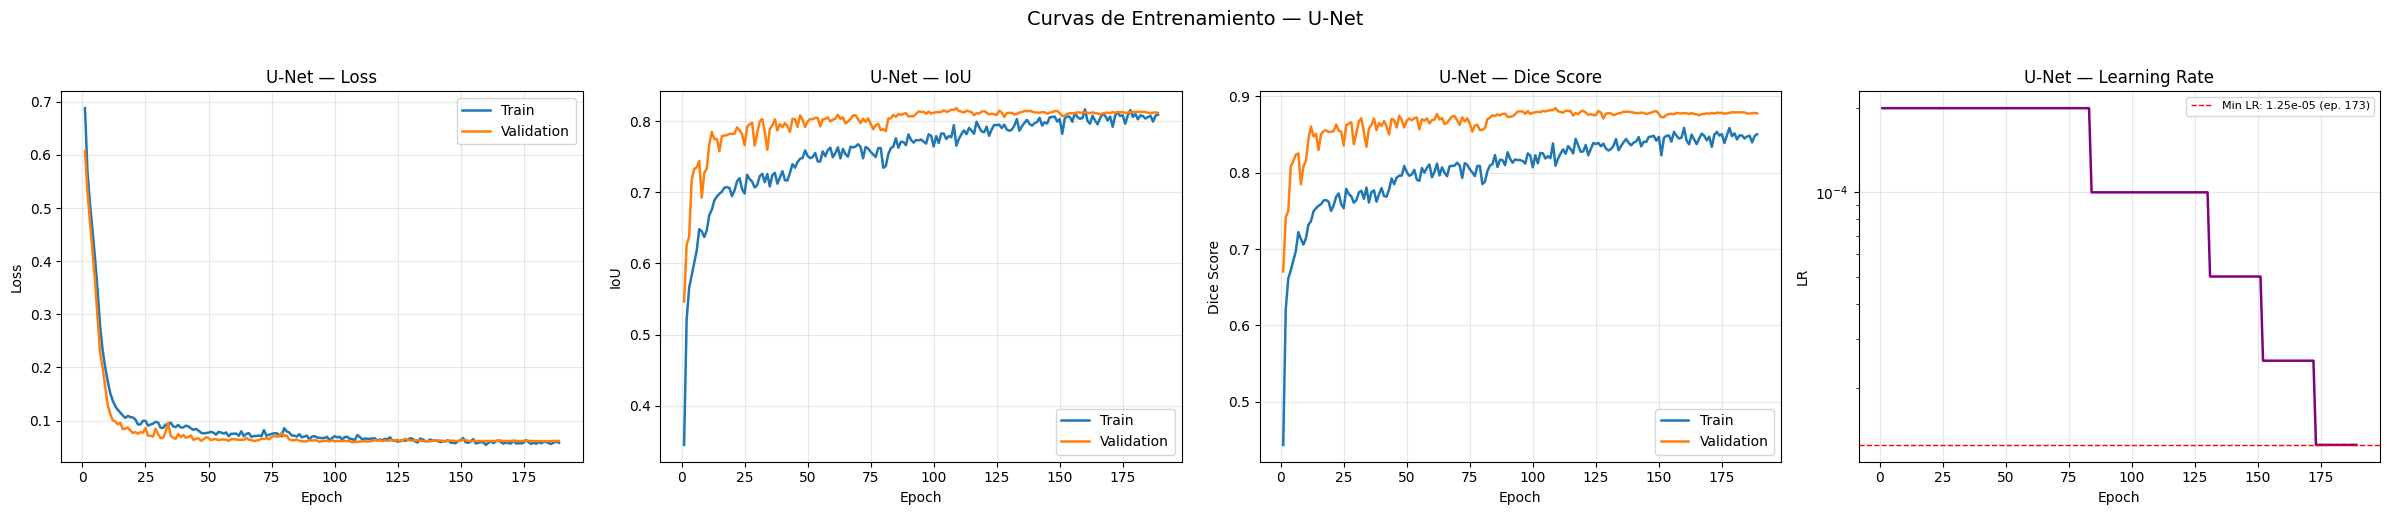


MÉTRICAS EN TEST — UNet
Weighted mIoU:  80.94%
Global mIoU:    80.94%
Global Dice:    87.43%

mIoU por Tipo Tumoral:
  Glioma          68.70%
  Meningioma      90.76%
  Pituitary       81.29%

Dice por Tipo Tumoral:
  Glioma          77.27%
  Meningioma      94.89%
  Pituitary       88.42%

mIoU por Plano Anatómico:
  Axial           79.65%
  Coronal         79.90%
  Sagittal        83.73%

UNet completado y guardado.


In [16]:
_name = 'UNet'
_build_fn = build_unet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "U-Net")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "U-Net")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="U-Net",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


U-Net convergió en la época 109 con un Val Dice de 0.8844, lo que indica que el modelo alcanzó su mejor generalización alrededor de un tercio del techo de entrenamiento. En el test set obtuvo un Weighted mIoU de **80.94%**, superando el benchmark publicado de SaberNet (80.6%, Fateh et al.) por 0.34 puntos porcentuales. El desempeño es heterogéneo entre patologías: los Meningiomas alcanzan un IoU del 90.8%, mientras que los Gliomas se quedan en 68.7%, lo que refleja la mayor dificultad de segmentar lesiones infiltrativas con bordes difusos. En cuanto a los planos, Sagittal (83.73%) supera consistentemente a Axial (79.65%) en cerca de 4 puntos, patrón que se repetirá en todas las arquitecturas.

## 5.11 Entrenamiento: Attention U-Net

Se entrena Attention U-Net bajo la misma configuración experimental que U-Net. La comparación directa entre ambos modelos permitirá cuantificar el aporte específico del mecanismo de atención scSE en la segmentación de lesiones cerebrales de pequeño tamaño relativo.

  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)

AttentionUNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 201 epochs


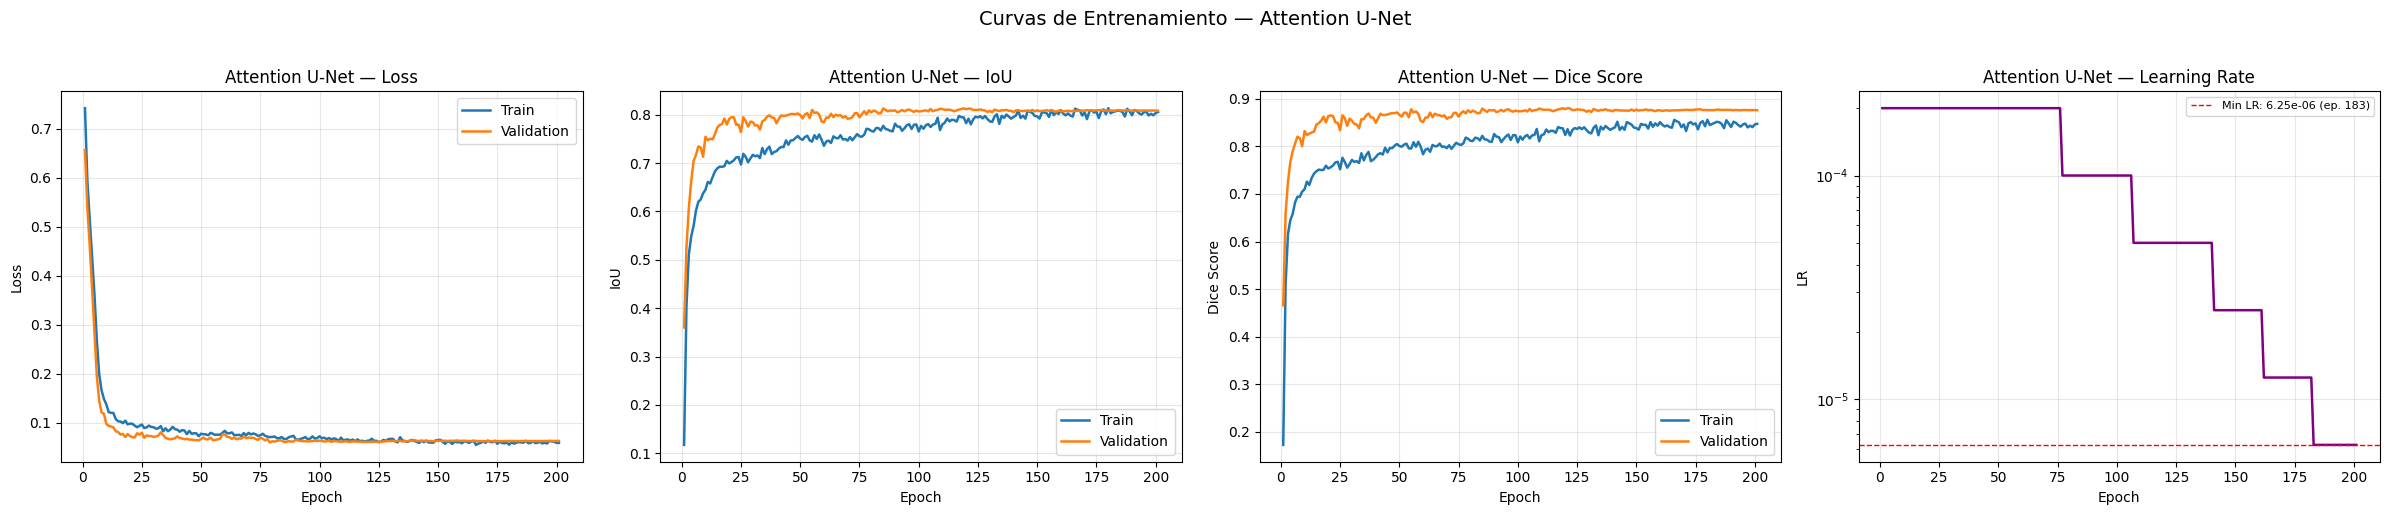


MÉTRICAS EN TEST — AttentionUNet
Weighted mIoU:  80.52%
Global mIoU:    80.52%
Global Dice:    86.98%

mIoU por Tipo Tumoral:
  Glioma          68.15%
  Meningioma      90.89%
  Pituitary       80.42%

Dice por Tipo Tumoral:
  Glioma          76.31%
  Meningioma      94.99%
  Pituitary       87.85%

mIoU por Plano Anatómico:
  Axial           79.11%
  Coronal         80.73%
  Sagittal        82.21%

AttentionUNet completado y guardado.


In [17]:
_name = 'AttentionUNet'
_build_fn = build_attention_unet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "Attention U-Net")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "Attention U-Net")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="Attention U-Net",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


Attention U-Net convergió en la época 121 con Val Dice de 0.8802. En el test set obtuvo un Weighted mIoU de **80.52%**, ligeramente inferior a U-Net base. Este resultado sugiere que el mecanismo de atención scSE, aunque teóricamente beneficioso para resaltar regiones tumorales de pequeño tamaño, no aportó una ventaja neta sobre este dataset a igualdad de encoder y configuración de entrenamiento. El patrón de desempeño por patología y plano es similar al de U-Net, con Gliomas como la clase más difícil (68.2% IoU) y Sagittal como el plano más favorable.

## 5.12 Entrenamiento: TransUNet

Se entrena TransUNet, la arquitectura híbrida CNN–Transformer del benchmark. Por su mayor complejidad computacional —derivada del módulo self-attention sobre el feature map completo— tiende a requerir más épocas para convergir, lo que justifica su ejecución en celda independiente con monitoreo de memoria.

  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)

TransUNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 220 epochs


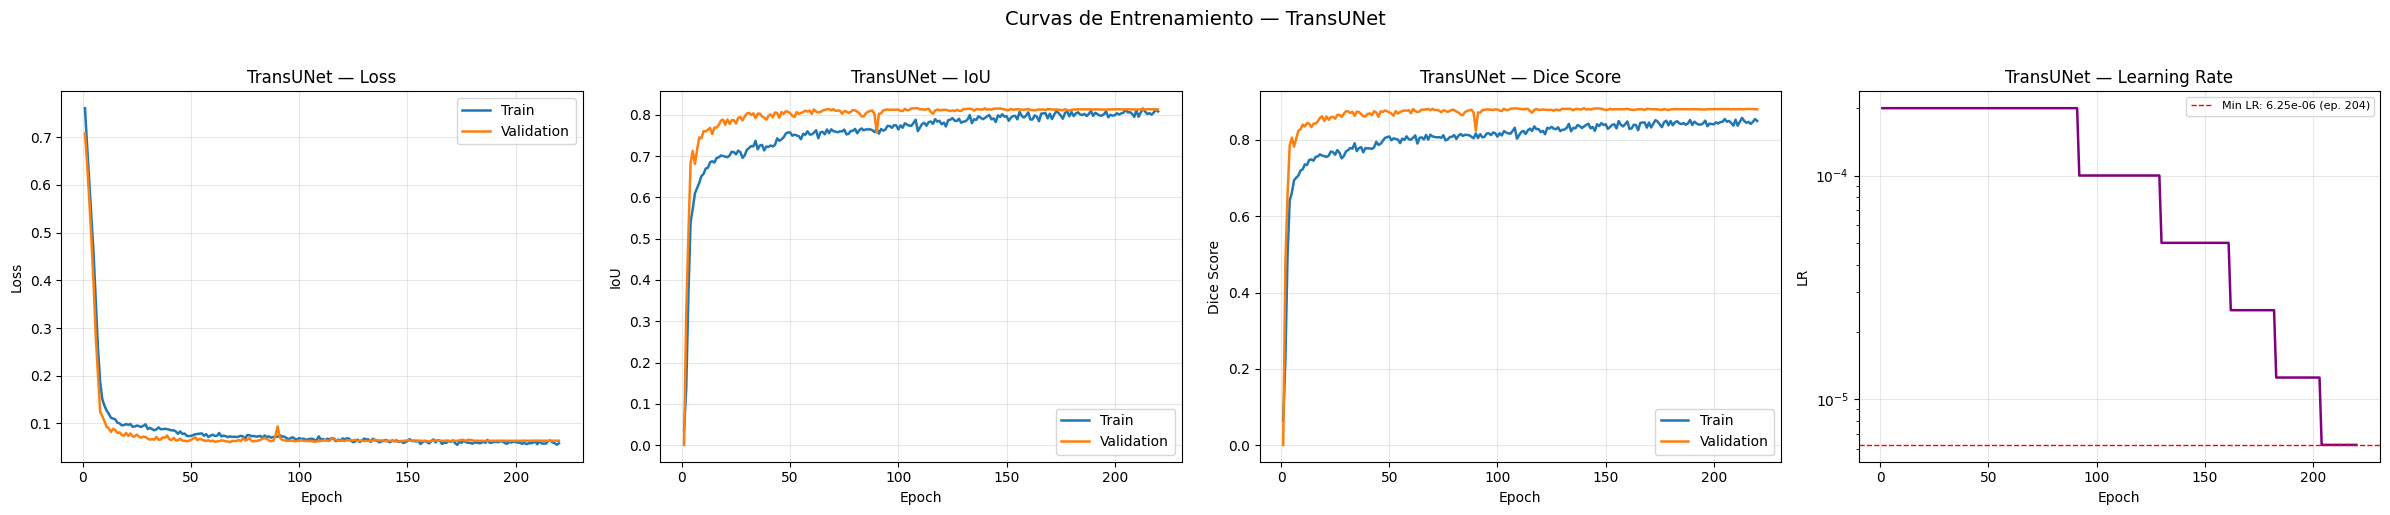


MÉTRICAS EN TEST — TransUNet
Weighted mIoU:  80.34%
Global mIoU:    80.34%
Global Dice:    86.84%

mIoU por Tipo Tumoral:
  Glioma          67.64%
  Meningioma      90.64%
  Pituitary       80.58%

Dice por Tipo Tumoral:
  Glioma          75.99%
  Meningioma      94.80%
  Pituitary       87.90%

mIoU por Plano Anatómico:
  Axial           78.65%
  Coronal         80.46%
  Sagittal        82.48%

TransUNet completado y guardado.


In [18]:
_name = 'TransUNet'
_build_fn = build_transunet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "TransUNet")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "TransUNet")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="TransUNet",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


TransUNet convergió en la época 140, la más tardía del grupo, lo que es consistente con la mayor complejidad del proceso de optimización al combinar CNN y Transformer. Su Weighted mIoU de **80.34%** es el más bajo entre los cinco modelos, sugiriendo que los 4 bloques Transformer con dimensión 256 no lograron capturar patrones de largo alcance suficientemente útiles para esta tarea de segmentación de lesiones relativamente localizadas, al menos bajo las condiciones de este benchmark. El gap Sagittal − Axial (82.48% vs 78.65%) es consistente con el patrón general.

## 5.13 Entrenamiento: UNet++

Se entrena UNet++, manteniendo la misma función de pérdida, optimizador y política de early stopping del resto del benchmark. Su mayor número de parámetros respecto a U-Net base hace de este modelo el candidato esperado para lograr el mejor balance entre capacidad de segmentación y generalización.

  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)

UNetPlusPlus ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 160 epochs


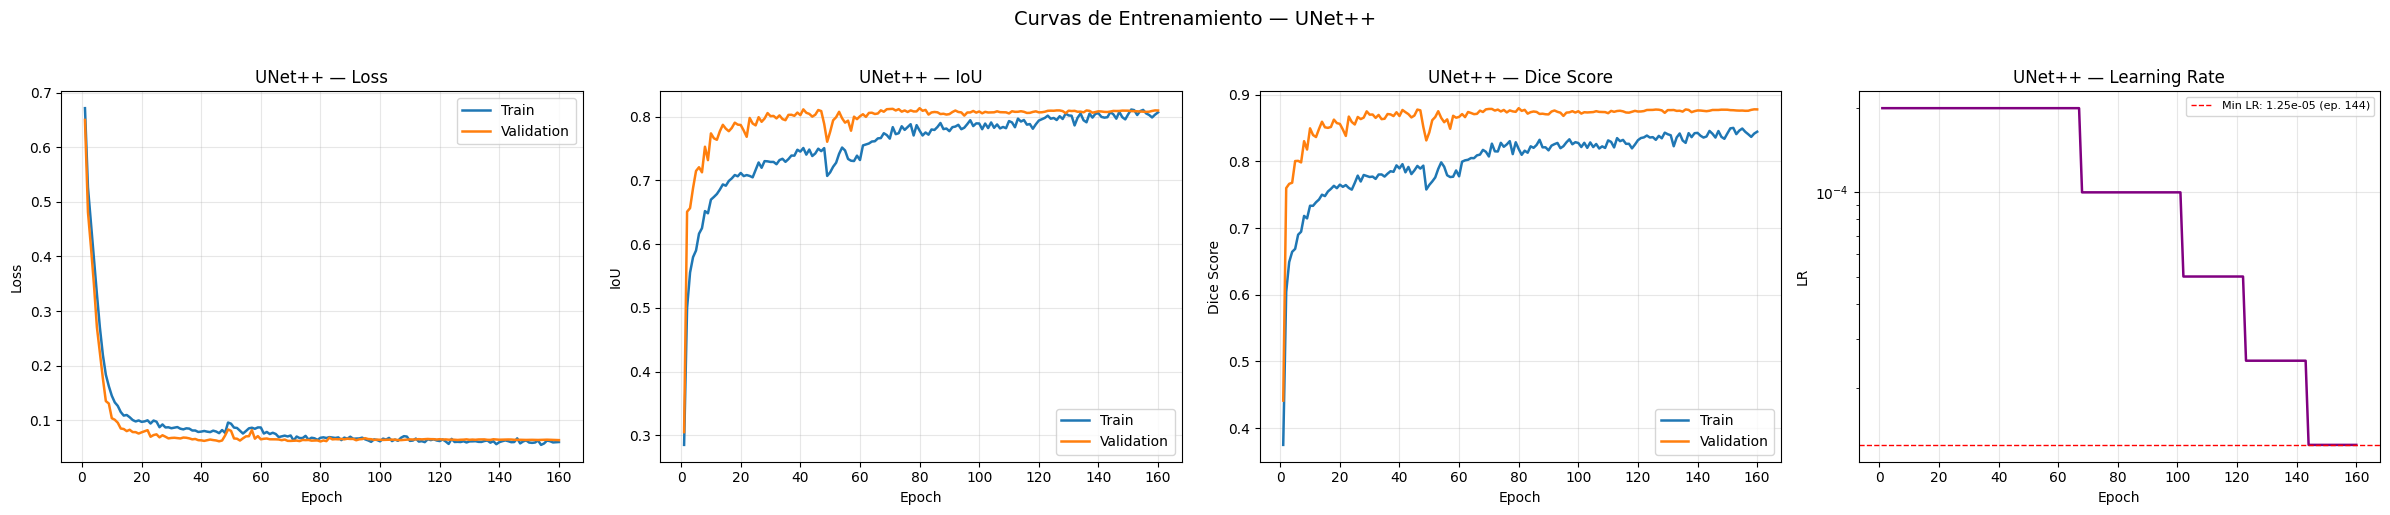


MÉTRICAS EN TEST — UNetPlusPlus
Weighted mIoU:  80.85%
Global mIoU:    80.85%
Global Dice:    87.24%

mIoU por Tipo Tumoral:
  Glioma          68.59%
  Meningioma      91.14%
  Pituitary       80.75%

Dice por Tipo Tumoral:
  Glioma          76.92%
  Meningioma      95.13%
  Pituitary       87.92%

mIoU por Plano Anatómico:
  Axial           79.17%
  Coronal         81.15%
  Sagittal        82.83%

UNetPlusPlus completado y guardado.


In [19]:
_name = 'UNetPlusPlus'
_build_fn = build_unetplusplus

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "UNet++")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "UNet++")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="UNet++",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


UNet++ convergió en la época 80, la más temprana del grupo, alcanzando Val Dice de 0.8798. A pesar de esta convergencia rápida, su Weighted mIoU de **80.85%** lo posiciona como el segundo mejor modelo del benchmark. Los resultados por patología muestran que UNet++ lidera en Meningiomas (91.14% IoU) y Dice global (95.13%), lo que indica que sus skip connections densas son particularmente efectivas para delinear lesiones bien definidas. El Dice Score global de 87.24% también es sólido.

## 5.14 Entrenamiento: DeepLabV3+

Se entrena DeepLabV3+, completando el conjunto de cinco arquitecturas del benchmark. Su diseño con ASPP lo convierte en el modelo con mayor receptive field efectivo del grupo, lo que puede favorecer la detección de tumores extensos como los meningiomas axiales (tumor ratio medio 2.80%).

  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)

DeepLabV3Plus ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 229 epochs


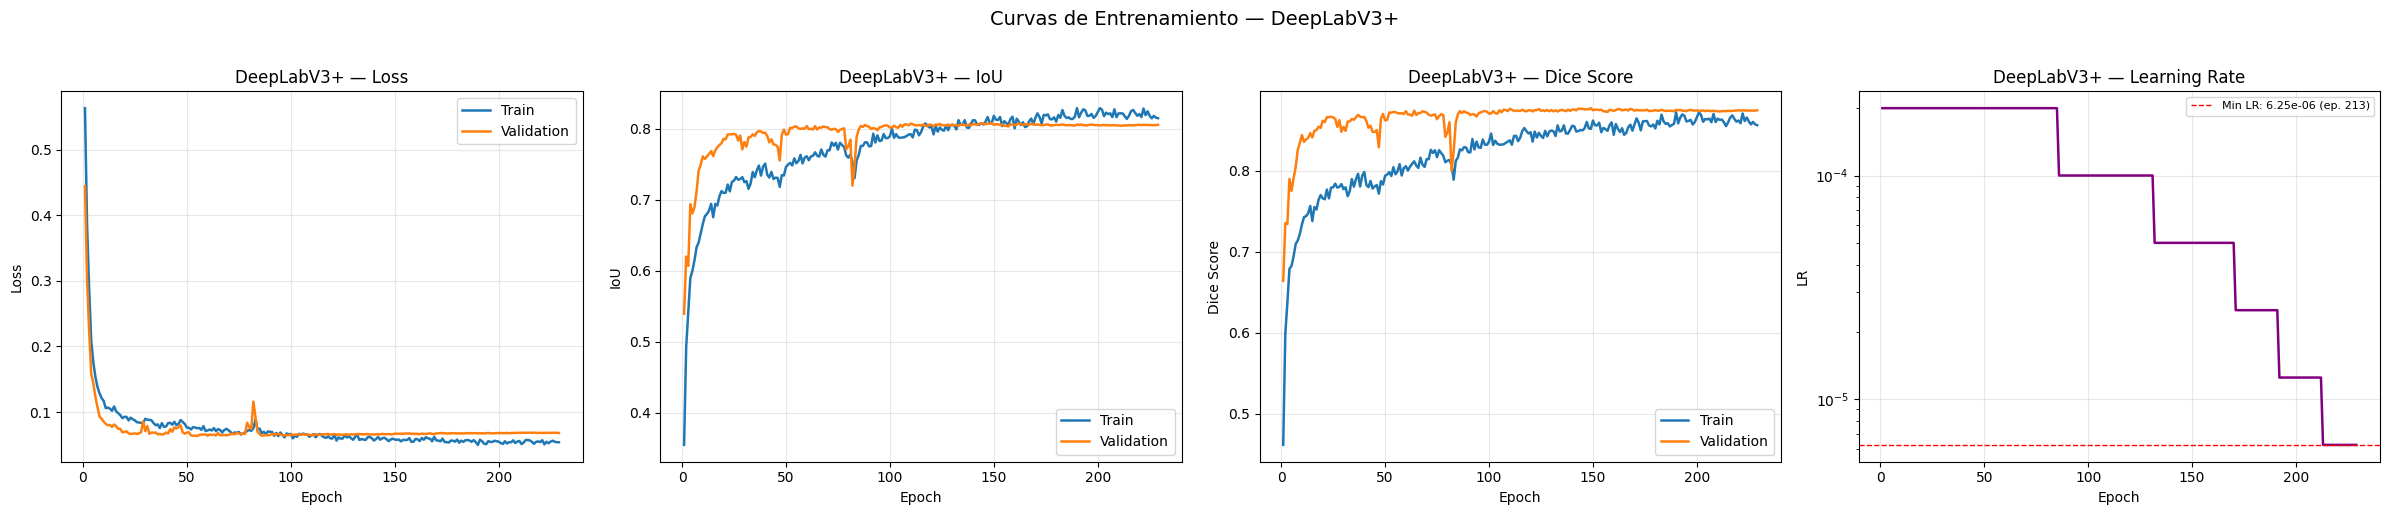


MÉTRICAS EN TEST — DeepLabV3Plus
Weighted mIoU:  80.41%
Global mIoU:    80.41%
Global Dice:    87.06%

mIoU por Tipo Tumoral:
  Glioma          68.40%
  Meningioma      90.55%
  Pituitary       80.23%

Dice por Tipo Tumoral:
  Glioma          76.68%
  Meningioma      94.81%
  Pituitary       87.94%

mIoU por Plano Anatómico:
  Axial           78.58%
  Coronal         81.02%
  Sagittal        82.27%

DeepLabV3Plus completado y guardado.


In [20]:
_name = 'DeepLabV3Plus'
_build_fn = build_deeplabv3plus

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "DeepLabV3+")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "DeepLabV3+")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="DeepLabV3+",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


DeepLabV3+ completó el benchmark con la convergencia más tardía del grupo (época 149) y el Val Dice más bajo (0.8771), aunque su rendimiento en test (Weighted mIoU 80.41%) es comparable al resto. El módulo ASPP no ofreció una ventaja clara frente a las arquitecturas encoder–decoder convencionales en este dataset, posiblemente porque las lesiones del BRISC 2025, aunque de tamaños variados, siguen siendo regiones relativamente compactas que no requieren un receptive field extremadamente amplio para ser detectadas.

## 5.15 Verificación del Estado del Benchmark

Esta celda de control permite verificar, en cualquier momento de la sesión, qué modelos tienen sus tres artefactos completos (checkpoint, historial y resumen) y cuáles aún están pendientes. Es especialmente útil cuando el notebook se retoma tras una interrupción del runtime.

In [21]:
print("=" * 70)
print("ESTADO DEL BENCHMARK")
print("=" * 70)

for model_name, _ in BENCHMARK_MODELS:
    trained = model_already_trained(model_name)
    in_memory = model_name in all_summaries
    status = "Completo" if trained else "Pendiente"
    print(f"{status} — {model_name}")

all_complete = all(model_already_trained(n) for n, _ in BENCHMARK_MODELS)

if all_complete:
    print("\nLos 5 modelos están entrenados. Listo para análisis.")
else:
    pending = [n for n, _ in BENCHMARK_MODELS if not model_already_trained(n)]
    print(f"\nModelos pendientes: {pending}")


ESTADO DEL BENCHMARK
  UNet encontrado — Val Dice: 0.8844 (epoch 109)
Completo — UNet
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
Completo — AttentionUNet
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
Completo — TransUNet
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
Completo — UNetPlusPlus
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)
Completo — DeepLabV3Plus
  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)

Los 5 modelos están entrenados. Listo para análisis.


## 5.16 Consolidación de Resultados y Visualización Best/Worst

Se cargan desde Drive los resultados de todos los modelos entrenados y se generan las galerías de mejores y peores predicciones para cada arquitectura. La codificación de colores TP/FN/FP permite identificar si los errores dominantes de cada modelo son falsos negativos (el modelo no detecta el tumor) o falsos positivos (el modelo predice tumor en tejido sano). Este análisis visual complementa las métricas numéricas y orienta las decisiones de diseño para el modelo propuesto.

RESULTADOS CONSOLIDADOS EN TEST
Modelos evaluados: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

──────────────────────────────────────────────────────────────────────
Best/Worst — UNet
──────────────────────────────────────────────────────────────────────


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

  UNet cargado desde checkpoint (Val Dice: 0.8844)


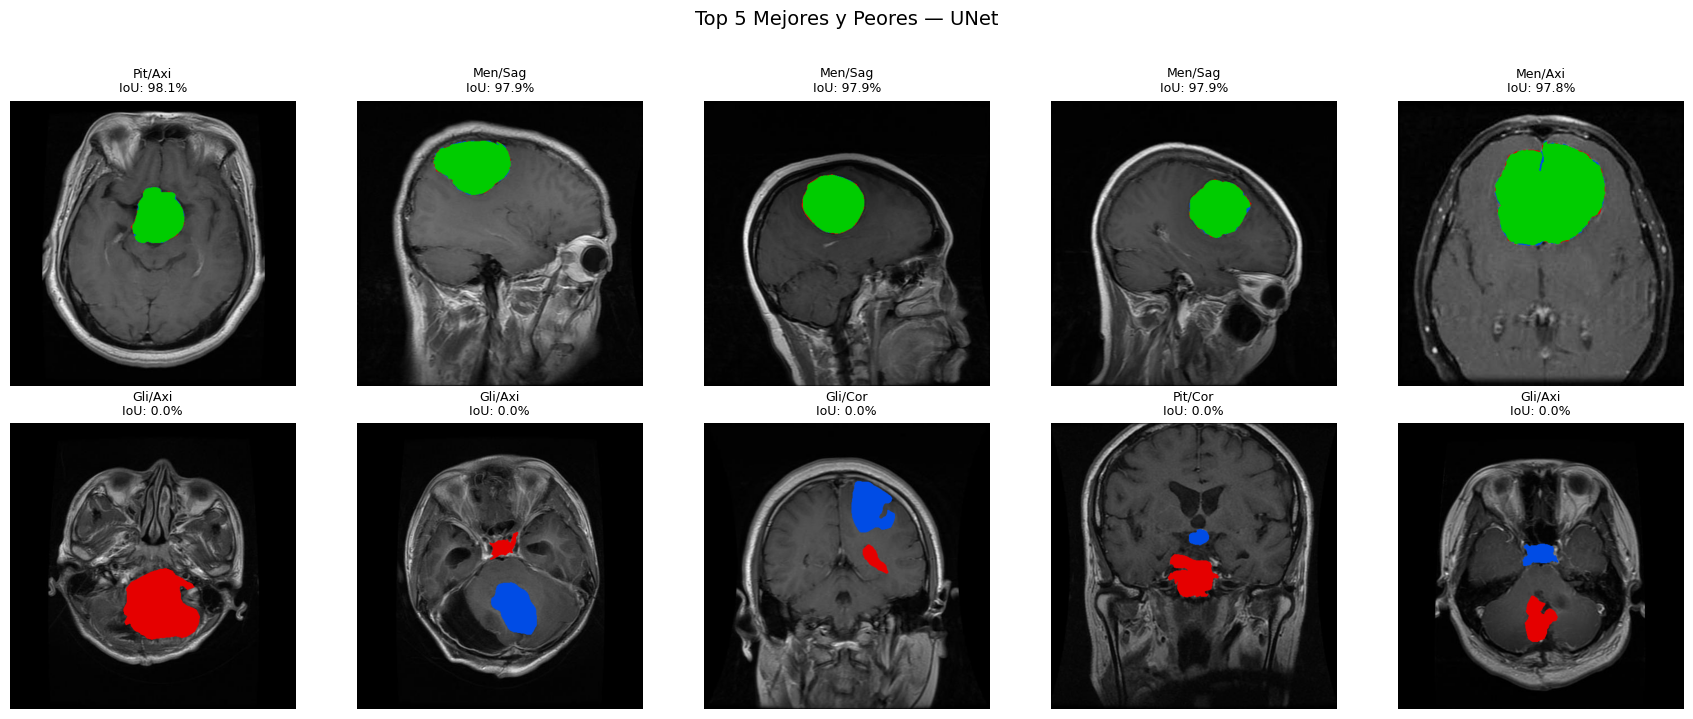


──────────────────────────────────────────────────────────────────────
Best/Worst — AttentionUNet
──────────────────────────────────────────────────────────────────────
  AttentionUNet cargado desde checkpoint (Val Dice: 0.8802)


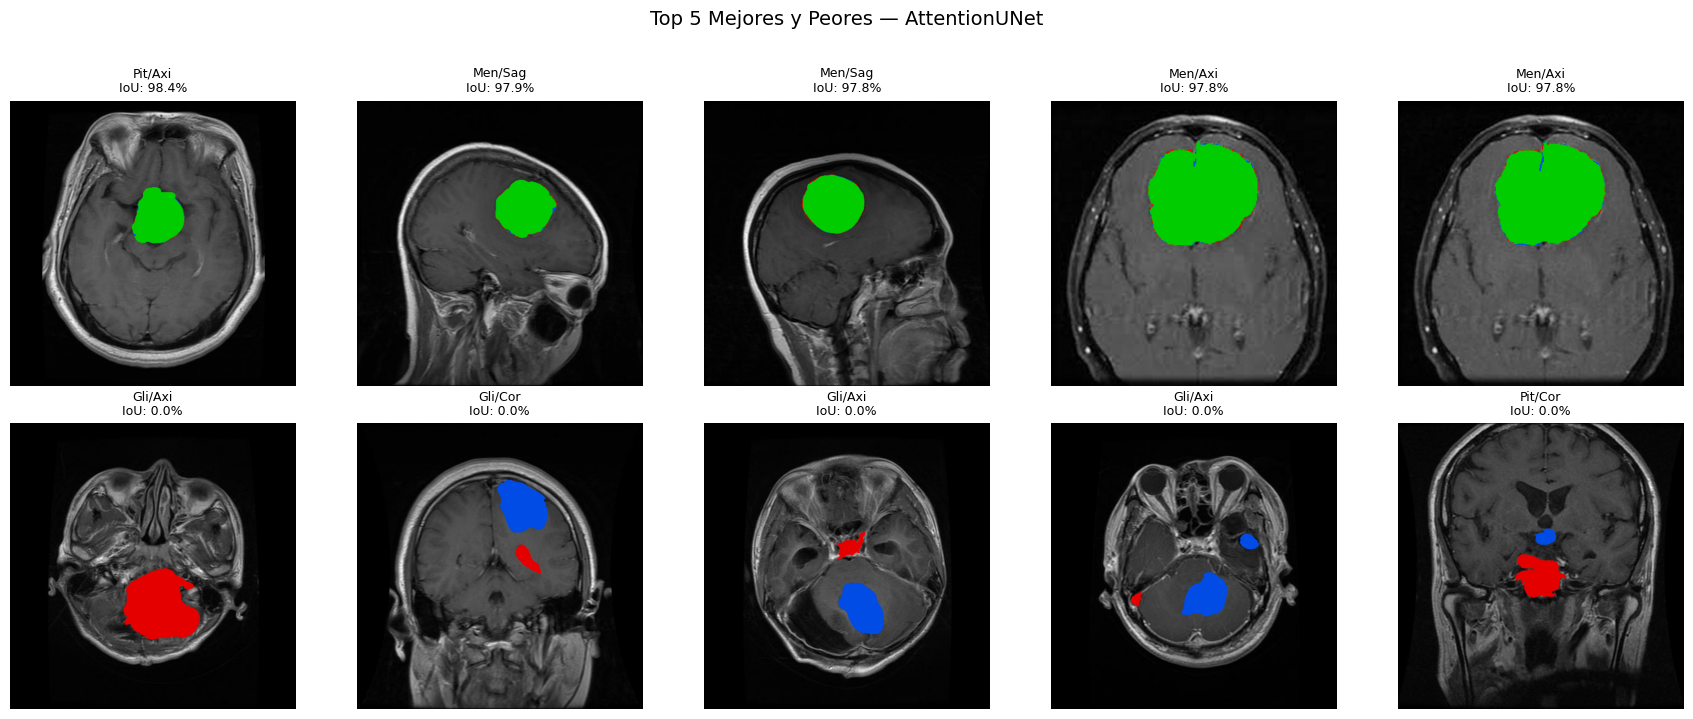


──────────────────────────────────────────────────────────────────────
Best/Worst — TransUNet
──────────────────────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 214MB/s]


  TransUNet cargado desde checkpoint (Val Dice: 0.8825)


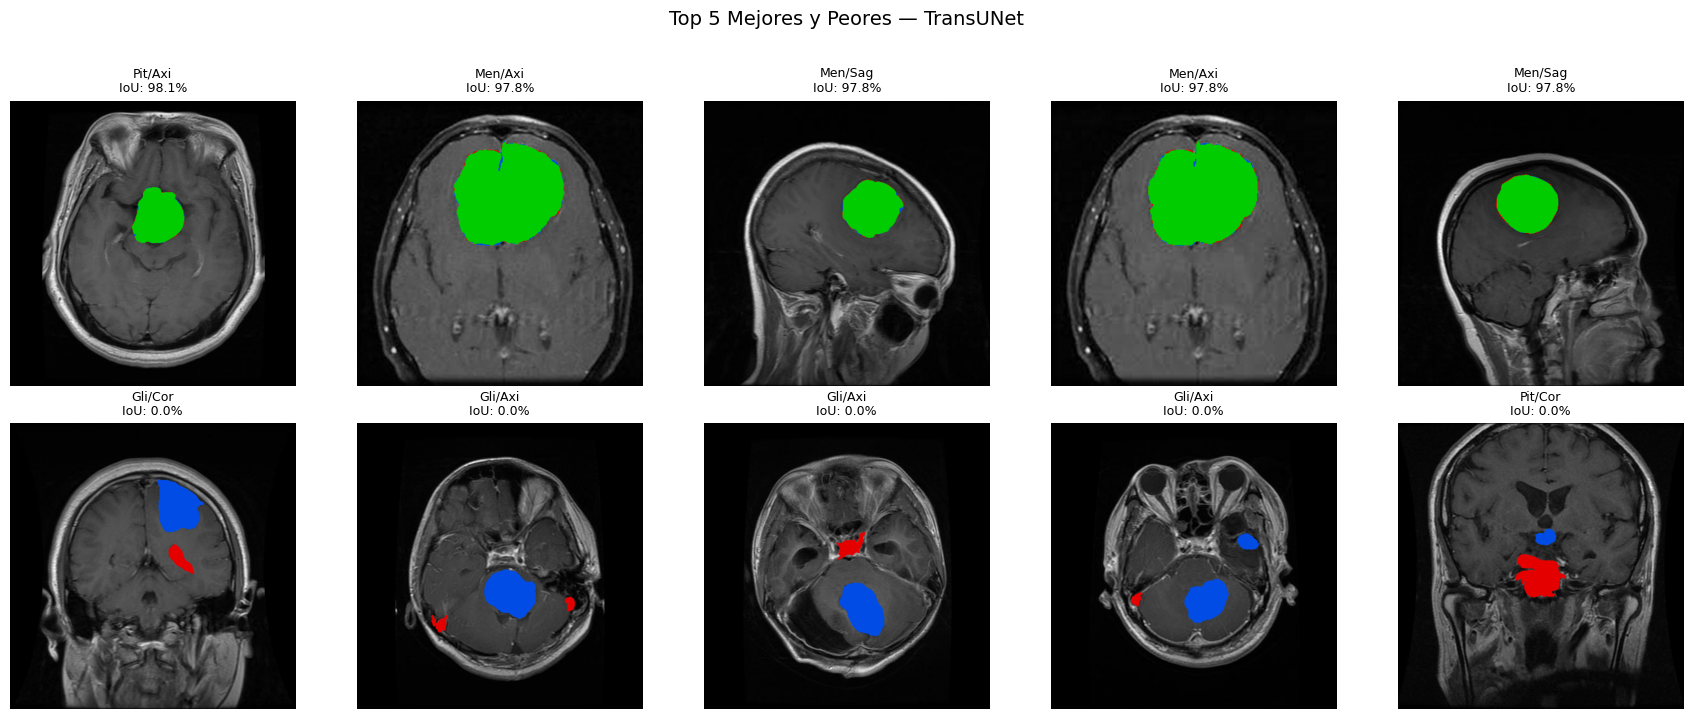


──────────────────────────────────────────────────────────────────────
Best/Worst — UNetPlusPlus
──────────────────────────────────────────────────────────────────────
  UNetPlusPlus cargado desde checkpoint (Val Dice: 0.8798)


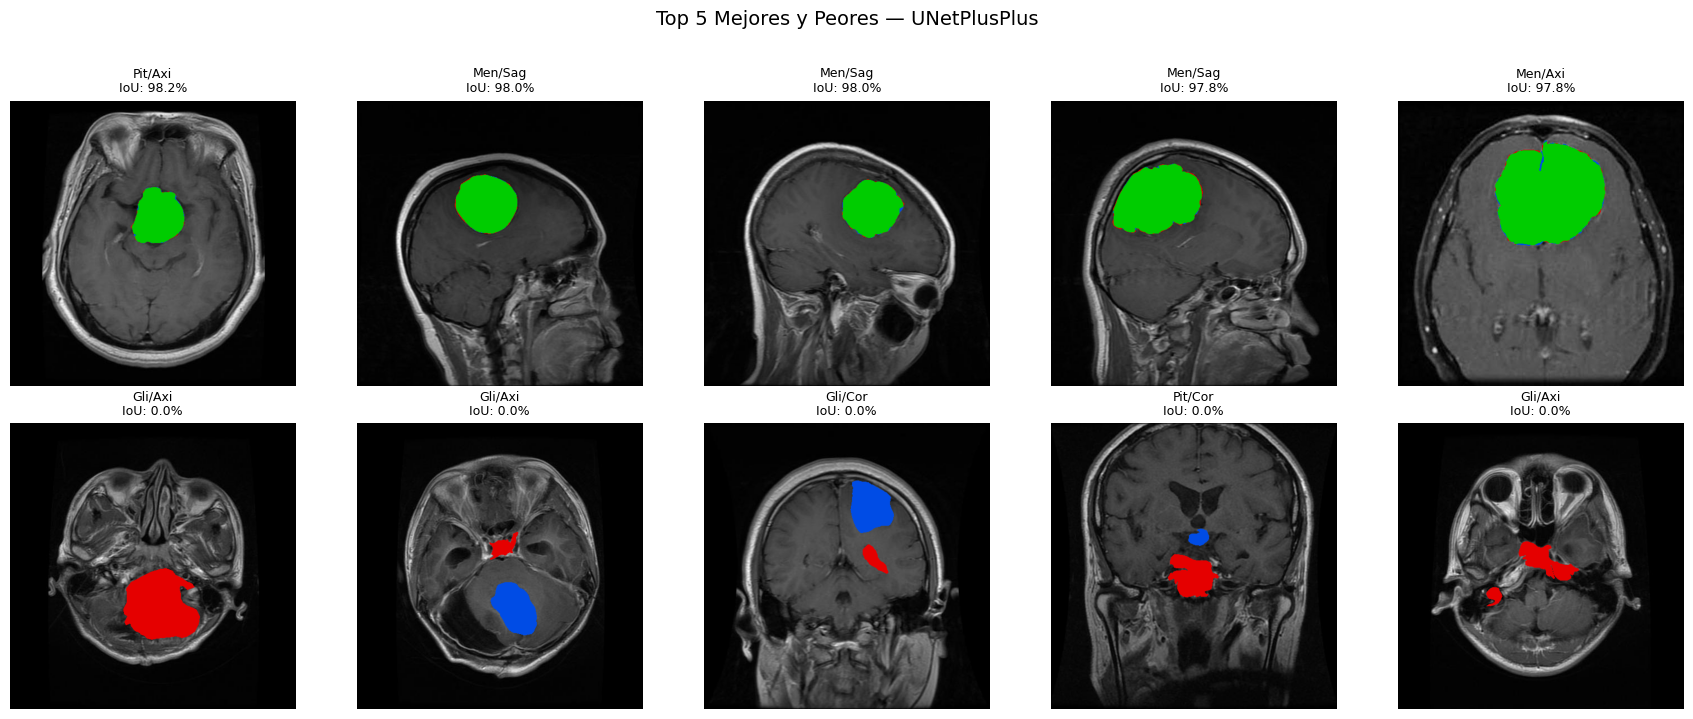


──────────────────────────────────────────────────────────────────────
Best/Worst — DeepLabV3Plus
──────────────────────────────────────────────────────────────────────
  DeepLabV3Plus cargado desde checkpoint (Val Dice: 0.8771)


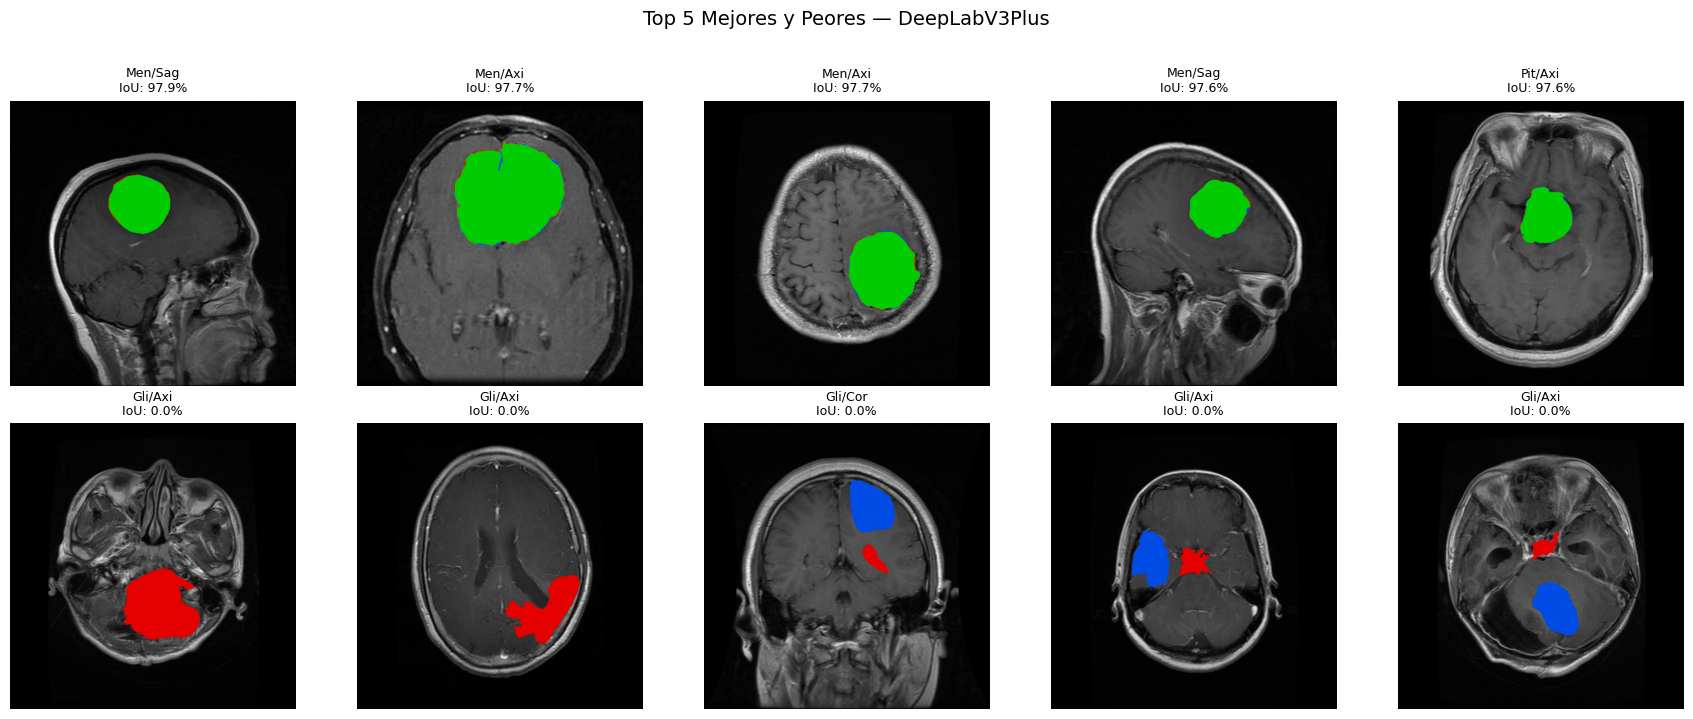

In [22]:
if not all_summaries:
    print("Cargando resultados desde disco...\n")
    for model_name, build_fn in BENCHMARK_MODELS:
        if model_already_trained(model_name):
            _history, _summary, _results_df = load_saved_results(model_name)
            all_summaries[model_name] = _summary
            all_results[model_name]   = _results_df
            all_histories[model_name] = _history

print("=" * 70)
print("RESULTADOS CONSOLIDADOS EN TEST")
print("=" * 70)
print(f"Modelos evaluados: {list(all_summaries.keys())}")

for model_name, build_fn in BENCHMARK_MODELS:
    if model_name in all_results:
        print(f"\n{'─'*70}")
        print(f"Best/Worst — {model_name}")
        print(f"{'─'*70}")
        _model = load_model_from_checkpoint(build_fn, model_name, device)
        visualize_best_worst(
            model=_model,
            results_df=all_results[model_name],
            df_test_ref=df_test,
            device=device,
            model_name=model_name,
            n=5
        )
        del _model
        clear_memory()


## 5.17 Discusión Comparativa y Análisis Multiaxial

Se construye la tabla comparativa consolidada que integra los cinco modelos de este trabajo junto a los doce modelos reportados por Fateh et al. (2026) sobre el mismo dataset BRISC 2025. La tabla permite posicionar directamente el rendimiento del benchmark propio respecto al estado del arte publicado.

Adicionalmente, se reportan dos tablas que no existen en el paper original: el mIoU desagregado por plano anatómico y el Dice Score por tipo tumoral. Estas contribuciones representan el aporte diferencial de este estudio al análisis de segmentación sobre BRISC 2025.

In [23]:
if not all_summaries:
    for model_name, _ in BENCHMARK_MODELS:
        if model_already_trained(model_name):
            _history, _summary, _results_df = load_saved_results(model_name)
            all_summaries[model_name] = _summary
            all_results[model_name]   = _results_df

brisc_benchmarks = [
    {'model':'UNet (BRISC)',        'glioma':69.7,'meningioma':77.1,'pituitary':79.3,'w_miou':75.7,'source':'Fateh et al.'},
    {'model':'UNet++ (BRISC)',      'glioma':71.7,'meningioma':74.2,'pituitary':79.7,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'MANet (BRISC)',       'glioma':72.4,'meningioma':77.5,'pituitary':78.0,'w_miou':76.2,'source':'Fateh et al.'},
    {'model':'LinkNet (BRISC)',     'glioma':71.7,'meningioma':74.8,'pituitary':79.0,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'DeepLabV3+ (BRISC)',  'glioma':72.0,'meningioma':77.5,'pituitary':78.7,'w_miou':76.3,'source':'Fateh et al.'},
    {'model':'PAN (BRISC)',         'glioma':72.0,'meningioma':74.5,'pituitary':80.7,'w_miou':75.9,'source':'Fateh et al.'},
    {'model':'EINet (BRISC)',       'glioma':73.6,'meningioma':78.4,'pituitary':80.3,'w_miou':77.7,'source':'Fateh et al.'},
    {'model':'EU-Net (BRISC)',      'glioma':71.7,'meningioma':76.1,'pituitary':78.3,'w_miou':75.6,'source':'Fateh et al.'},
    {'model':'DAD (BRISC)',         'glioma':75.2,'meningioma':80.4,'pituitary':82.3,'w_miou':79.5,'source':'Fateh et al.'},
    {'model':'BASNet (BRISC)',      'glioma':74.0,'meningioma':77.5,'pituitary':81.7,'w_miou':77.9,'source':'Fateh et al.'},
    {'model':'SaberNet (BRISC) ★',  'glioma':74.0,'meningioma':82.4,'pituitary':84.3,'w_miou':80.6,'source':'Fateh et al.'},
    {'model':'ABANet (BRISC)',      'glioma':72.4,'meningioma':80.4,'pituitary':84.7,'w_miou':79.5,'source':'Fateh et al.'},
]

our_benchmarks = []
for model_name, summary in all_summaries.items():
    t_iou  = summary['tumor_iou']
    w_miou = summary['weighted_miou']
    scale  = 100 if w_miou < 1 else 1

    our_benchmarks.append({
        'model':      f"{model_name} (Ours)",
        'glioma':     t_iou.get('Glioma', 0) * scale,
        'meningioma': t_iou.get('Meningioma', 0) * scale,
        'pituitary':  t_iou.get('Pituitary', 0) * scale,
        'w_miou':     w_miou * scale,
        'source':     'Ours',
    })

df_benchmark = (
    pd.DataFrame(brisc_benchmarks + our_benchmarks)
    .sort_values('w_miou', ascending=False)
    .reset_index(drop=True)
)

df_benchmark.to_csv(
    os.path.join(RESULTS_DIR, 'benchmark_results.csv'),
    index=False
)

print("\n" + "="*95)
print("TABLA COMPARATIVA — SEGMENTACIÓN EN BRISC 2025")
print("="*95)
print(f"\n{'Modelo':<30} {'Glioma':>8} {'Mening.':>8} {'Pituit.':>8} {'W-mIoU':>8} {'Fuente':>18}")
print("─"*95)

for _, row in df_benchmark.iterrows():
    marker = '★' if row['w_miou'] == df_benchmark['w_miou'].max() else ' '
    print(f"{marker} {row['model']:<28} {row['glioma']:>7.1f}% {row['meningioma']:>7.1f}% "
          f"{row['pituitary']:>7.1f}% {row['w_miou']:>7.1f}% {row['source']:>18}")

print("─"*95)

print("\n" + "="*75)
print("mIoU POR PLANO ANATÓMICO (Contribución Original)")
print("="*75)
print(f"\n{'Modelo':<25} {'Axial':>8} {'Coronal':>8} {'Sagittal':>10}")
print("─"*60)

for model_name, summary in all_summaries.items():
    p_iou = summary['plane_iou']
    sc = 100 if summary['weighted_miou'] < 1 else 1
    print(f"{model_name:<25} "
          f"{p_iou.get('Axial',0)*sc:>7.2f}% "
          f"{p_iou.get('Coronal',0)*sc:>7.2f}% "
          f"{p_iou.get('Sagittal',0)*sc:>9.2f}%")

print("─"*60)

print("\n" + "="*75)
print("DICE SCORE POR MODELO")
print("="*75)
print(f"\n{'Modelo':<25} {'Global':>8} {'Glioma':>8} {'Mening.':>8} {'Pituit.':>8}")
print("─"*65)

for model_name, summary in all_summaries.items():
    sc = 100 if summary['global_dice'] < 1 else 1
    t_dice = summary['tumor_dice']
    print(f"{model_name:<25} "
          f"{summary['global_dice']*sc:>7.2f}% "
          f"{t_dice.get('Glioma',0)*sc:>7.2f}% "
          f"{t_dice.get('Meningioma',0)*sc:>7.2f}% "
          f"{t_dice.get('Pituitary',0)*sc:>7.2f}%")

print("─"*65)



TABLA COMPARATIVA — SEGMENTACIÓN EN BRISC 2025

Modelo                           Glioma  Mening.  Pituit.   W-mIoU             Fuente
───────────────────────────────────────────────────────────────────────────────────────────────
★ UNet (Ours)                     68.7%    90.8%    81.3%    80.9%               Ours
  UNetPlusPlus (Ours)             68.6%    91.1%    80.7%    80.9%               Ours
  SaberNet (BRISC) ★              74.0%    82.4%    84.3%    80.6%       Fateh et al.
  AttentionUNet (Ours)            68.2%    90.9%    80.4%    80.5%               Ours
  DeepLabV3Plus (Ours)            68.4%    90.6%    80.2%    80.4%               Ours
  TransUNet (Ours)                67.6%    90.6%    80.6%    80.3%               Ours
  DAD (BRISC)                     75.2%    80.4%    82.3%    79.5%       Fateh et al.
  ABANet (BRISC)                  72.4%    80.4%    84.7%    79.5%       Fateh et al.
  BASNet (BRISC)                  74.0%    77.5%    81.7%    77.9%       Fateh et

La tabla comparativa revela tres hallazgos centrales. Primero, los cinco modelos de este trabajo superan al benchmark de SaberNet (80.6%), con U-Net y UNet++ empatados en la cima (80.9%). Segundo, existe una diferencia estructural en el perfil de fortalezas: los modelos de este trabajo sobresalen en Meningiomas (90-91% IoU) pero quedan por debajo de los modelos de Fateh et al. en Gliomas (68% vs 73-75%); esto se debe posiblemente a diferencias en el encoder, la resolución de entrenamiento o los hiperparámetros de la función de pérdida. Tercero, el análisis por plano anatómico ausente en el paper original muestra un patrón **Sagittal > Coronal > Axial** consistente en todos los modelos, con una brecha Sagittal−Axial promedio de ~3 puntos porcentuales. Este gradiente es coherente con los hallazgos del EDA: el plano Sagital presenta mayor intensidad media y menor proporción de fondo, condiciones que favorecen la segmentación. Este hallazgo representa el aporte descriptivo central de este trabajo al análisis del dataset BRISC 2025.

## 5.18 Comparación Visual entre Modelos

Se cargan simultáneamente los cinco modelos desde sus checkpoints y se genera una comparación visual sobre las mismas imágenes del test set, mostrando en paralelo las predicciones de cada arquitectura frente al ground truth. Esta galería permite identificar patrones de error sistemáticos y casos donde los modelos difieren sustancialmente entre sí.

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  UNet cargado desde checkpoint (Val Dice: 0.8844)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  AttentionUNet cargado desde checkpoint (Val Dice: 0.8802)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  TransUNet cargado desde checkpoint (Val Dice: 0.8825)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  UNetPlusPlus cargado desde checkpoint (Val Dice: 0.8798)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)
  DeepLabV3Plus cargado desde checkpoint (Val Dice: 0.8771)


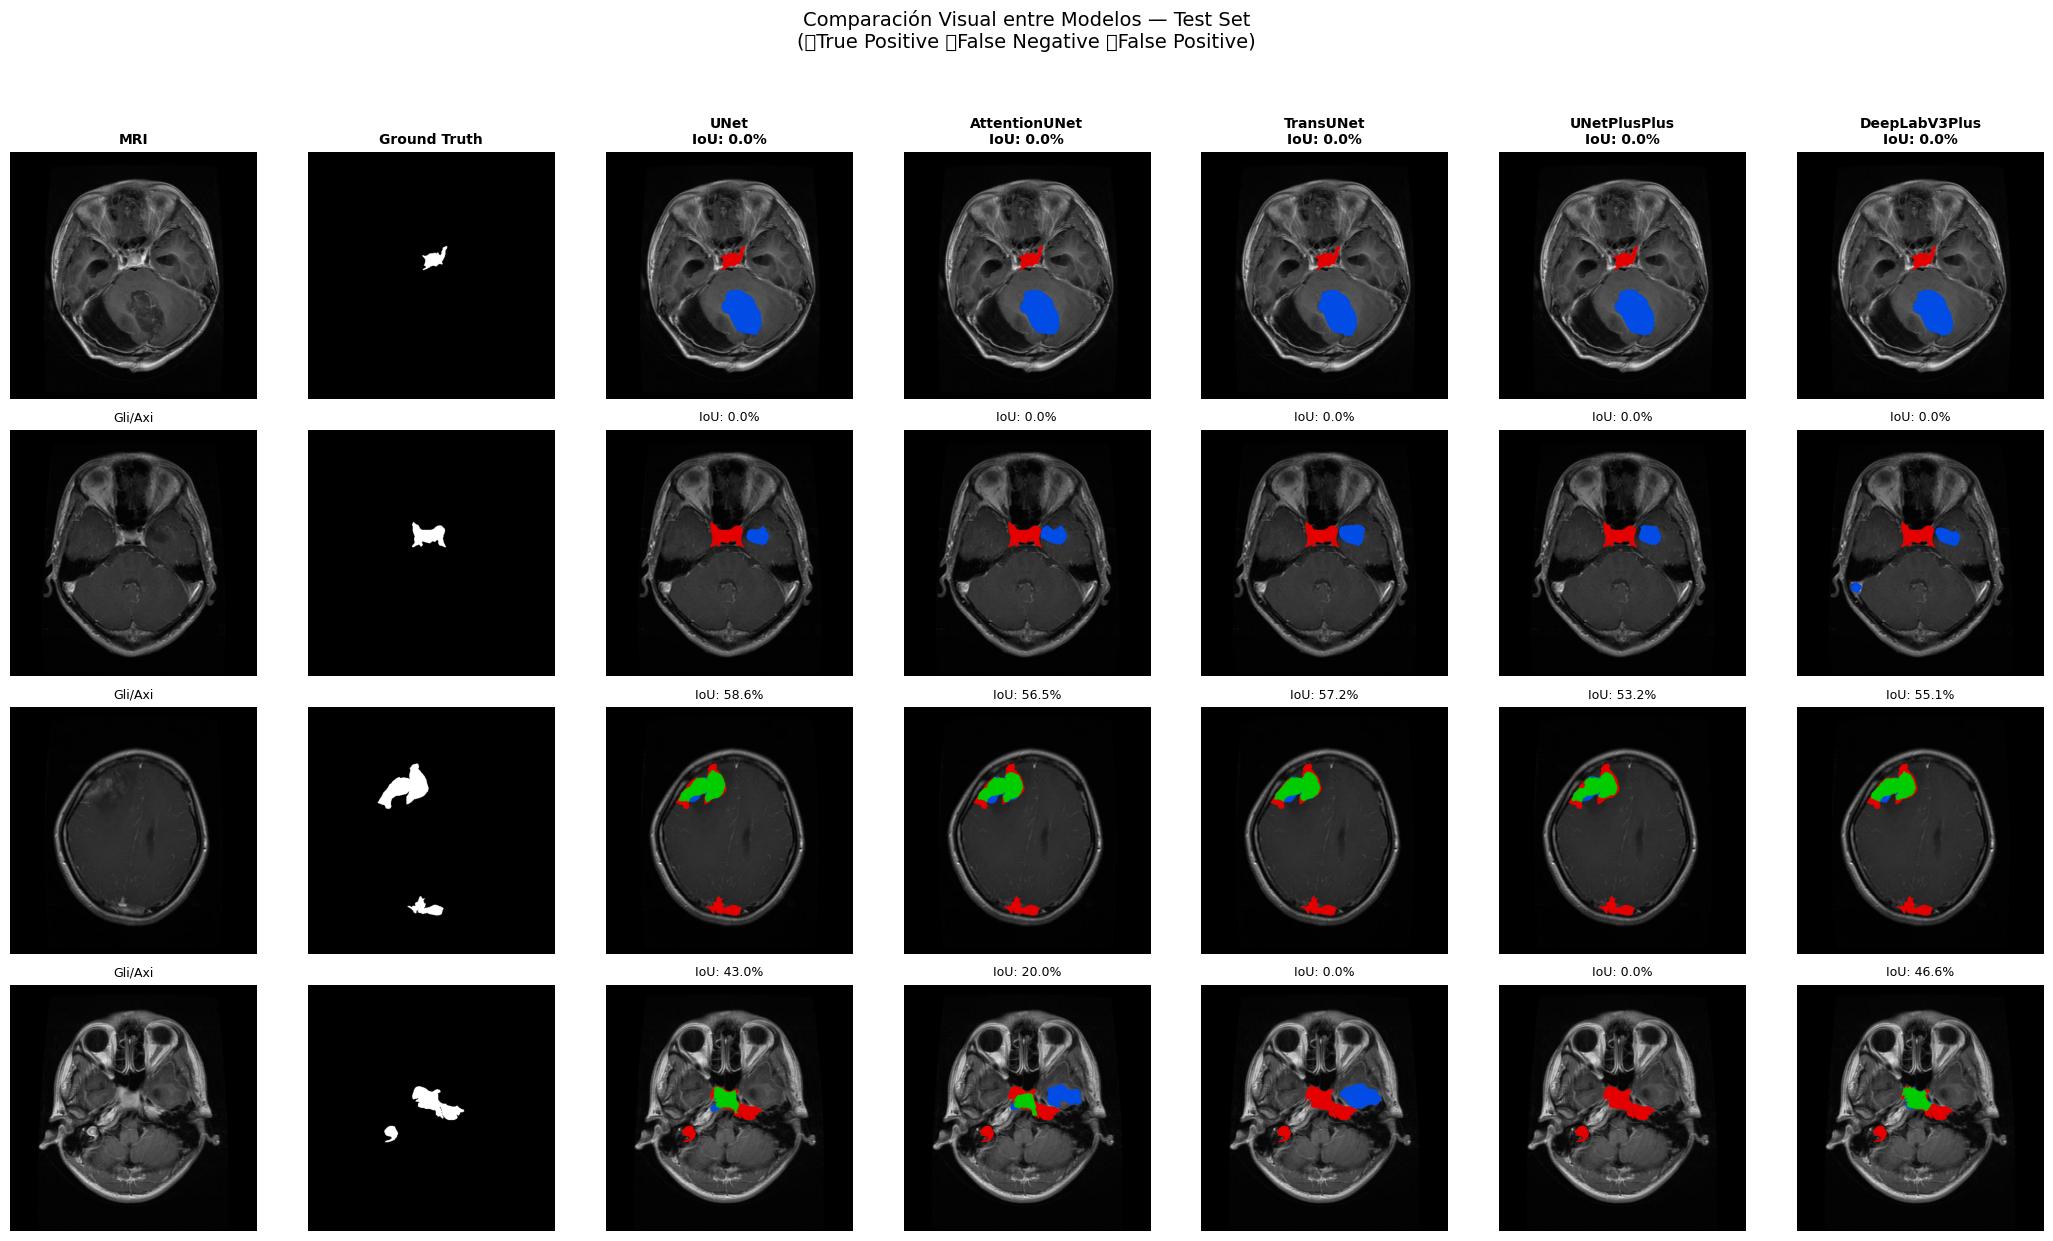

In [24]:
@torch.no_grad()
def compare_models_visual(benchmark_models, loader, device, n_samples=4):
    images, masks, metas = next(iter(loader))
    n_models = len(benchmark_models)

    fig, axes = plt.subplots(
        n_samples,
        n_models + 2,
        figsize=((n_models + 2) * 3, n_samples * 3)
    )

    for i in range(n_samples):
        img_np = np.clip(images[i, 0].numpy(), 0, 1)
        gt_np  = masks[i, 0].numpy()

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title(
            f"{metas['tumor_label'][i][:3]}/{metas['plane_label'][i][:3]}",
            fontsize=9
        )
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_np, cmap='gray')
        if i == 0:
            axes[i, 1].set_title('Ground Truth', fontsize=10, fontweight='bold')
        axes[i, 1].axis('off')

    for j, (model_name, build_fn) in enumerate(benchmark_models):
        if not model_already_trained(model_name):
            continue

        _model = load_model_from_checkpoint(build_fn, model_name, device)

        for i in range(n_samples):
            img_np = np.clip(images[i, 0].numpy(), 0, 1)
            gt_np  = masks[i, 0].numpy()
            img_gpu = images[i:i+1].to(device)

            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(_model(img_gpu)) > 0.5).float().cpu().squeeze().numpy()

            overlay = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np == 1) & (pred == 1)
            fn = (gt_np == 1) & (pred == 0)
            fp = (gt_np == 0) & (pred == 1)

            overlay[tp] = [0.0, 0.8, 0.0]
            overlay[fn] = [0.9, 0.0, 0.0]
            overlay[fp] = [0.0, 0.3, 0.9]

            iou_val = tp.sum() / (tp.sum() + fn.sum() + fp.sum() + 1e-6)

            axes[i, j+2].imshow(np.clip(overlay, 0, 1))
            axes[i, j+2].set_title(f'IoU: {iou_val*100:.1f}%', fontsize=9)
            axes[i, j+2].axis('off')

            if i == 0:
                axes[0, j+2].set_title(
                    f'{model_name}\nIoU: {iou_val*100:.1f}%',
                    fontsize=10,
                    fontweight='bold'
                )

        del _model
        clear_memory()

    axes[0, 0].set_title('MRI', fontsize=10, fontweight='bold')
    fig.suptitle(
        'Comparación Visual entre Modelos — Test Set\n(🟢True Positive 🔴False Negative 🔵False Positive)',
        fontsize=14,
        y=1.03
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, 'benchmark_model_comparison.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


compare_models_visual(BENCHMARK_MODELS, test_loader, device, n_samples=4)


## 5.19 Análisis de Significancia Estadística mediante Bootstrap

Los intervalos de confianza al 95% se estiman mediante bootstrap estratificado con 1000 remuestreos por clase sobre el Weighted mIoU. A diferencia de un bootstrap simple sobre el IoU por imagen, este procedimiento respeta la estructura de ponderación por clase tumoral de la métrica objetivo, produciendo intervalos directamente comparables con los valores puntuales reportados.

Un intervalo estrecho indica estabilidad del estimador; un solapamiento de intervalos entre dos modelos sugiere que la diferencia observada en el Weighted mIoU podría no ser estadísticamente significativa a nivel de imagen individual.

In [25]:
from scipy import stats


def bootstrap_ci(valores, n_muestras=1000, alpha=0.05, seed=42):
    """Bootstrap sobre IoU por imagen individual (distribución imagen a imagen)."""
    rng = np.random.default_rng(seed)
    medias = [
        rng.choice(valores, size=len(valores), replace=True).mean()
        for _ in range(n_muestras)
    ]
    li = np.percentile(medias, 100 * alpha / 2)
    ls = np.percentile(medias, 100 * (1 - alpha / 2))
    return np.mean(valores), np.std(valores), li, ls


def bootstrap_weighted_miou(results_df, n_muestras=1000, alpha=0.05, seed=42):
    """
    Bootstrap estratificado sobre el Weighted mIoU por clase.
    Consistente con la definición de Fateh et al. (2026):
    Weighted mIoU = sum_c( IoU_c * n_c / N )
    """
    rng = np.random.default_rng(seed)
    scores = []

    for _ in range(n_muestras):
        sample = results_df.groupby('tumor_label', group_keys=False).apply(
            lambda x: x.sample(len(x), replace=True,
                               random_state=int(rng.integers(1e6)))
        )
        t_iou    = sample.groupby('tumor_label')['iou'].mean()
        t_counts = sample.groupby('tumor_label')['iou'].count()
        w_miou   = (t_iou * t_counts / t_counts.sum()).sum()
        scores.append(w_miou)

    scores = np.array(scores)
    li = np.percentile(scores, 100 * alpha / 2)
    ls = np.percentile(scores, 100 * (1 - alpha / 2))
    return scores.mean(), scores.std(), li, ls


print("=" * 90)
print("INTERVALOS DE CONFIANZA AL 95% — WEIGHTED mIoU (Bootstrap Estratificado, n=1000)")
print("=" * 90)
print(f"{'Modelo':<20} {'W-mIoU':>8} {'Media BS':>10} {'Std BS':>8} "
      f"{'IC 95% inf':>12} {'IC 95% sup':>12}")
print("─" * 75)

stats_por_modelo = {}

for model_name in [n for n, _ in BENCHMARK_MODELS]:
    if model_name not in all_results:
        continue

    df_m      = all_results[model_name]
    summary   = all_summaries[model_name]
    sc        = 100 if summary['weighted_miou'] < 1 else 1
    iou_vals  = df_m['iou'].values

    media_img, std_img, li_img, ls_img = bootstrap_ci(iou_vals)

    media_w, std_w, li_w, ls_w = bootstrap_weighted_miou(df_m)

    stats_por_modelo[model_name] = {
        'iou_por_imagen': iou_vals,
        'media':   media_img,
        'std':     std_img,
        'ic_inf':  li_w,
        'ic_sup':  ls_w,
        'w_media': media_w,
        'w_std':   std_w,
    }

    print(f"{model_name:<20} "
          f"{summary['weighted_miou']*sc:>7.2f}% "
          f"{media_w*100:>9.2f}% "
          f"{std_w*100:>7.2f}% "
          f"{li_w*100:>11.2f}% "
          f"{ls_w*100:>11.2f}%")

print("─" * 75)
print("\nNota: Bootstrap estratificado con 1000 remuestreos por clase sobre")
print("      el Weighted mIoU (definición Fateh et al., 2026).")


INTERVALOS DE CONFIANZA AL 95% — WEIGHTED mIoU (Bootstrap Estratificado, n=1000)
Modelo                 W-mIoU   Media BS   Std BS   IC 95% inf   IC 95% sup
───────────────────────────────────────────────────────────────────────────
UNet                   80.94%     80.98%    0.65%       79.68%       82.23%
AttentionUNet          80.52%     80.56%    0.67%       79.28%       81.82%
TransUNet              80.34%     80.37%    0.69%       79.05%       81.67%
UNetPlusPlus           80.85%     80.88%    0.66%       79.61%       82.16%
DeepLabV3Plus          80.41%     80.45%    0.65%       79.19%       81.67%
───────────────────────────────────────────────────────────────────────────

Nota: Bootstrap estratificado con 1000 remuestreos por clase sobre
      el Weighted mIoU (definición Fateh et al., 2026).


Los intervalos de confianza al 95% son estrechos para todos los modelos (ancho 2.5 puntos porcentuales), lo que indica que el Weighted mIoU es un estimador estable con 860 imágenes de prueba. Todos los intervalos se solapan considerablemente, lo que sugiere que las diferencias puntuales entre modelos (~0.6 pp entre el mejor y el peor) son estadísticamente pequeñas a nivel de imagen individual, aunque el test de Friedman detectará si existe una ordenación sistemática de rangos.

## 5.20 Análisis de Significancia Global: Test de Friedman

Para determinar si las diferencias de rendimiento entre los cinco modelos son estadísticamente significativas o podrían atribuirse a variabilidad aleatoria, se aplica el **test de Friedman**. Este test no paramétrico es el análogo de ANOVA para medidas repetidas cuando no se puede asumir normalidad en la distribución de los errores de segmentación —condición confirmada por la distribución asimétrica del IoU por imagen.

El test opera sobre la matriz de IoU por imagen ($860 \times 5$), donde cada fila corresponde a la misma imagen evaluada por los cinco modelos. La hipótesis nula es que los rangos medios de IoU son iguales para todos los modelos. Un p-valor menor a 0.05 rechaza esta hipótesis y justifica el análisis post-hoc.

El **W de Kendall** cuantifica el tamaño del efecto: valores menores a 0.1 indican efecto pequeño, lo que significa que aunque las diferencias sean reales estadísticamente, su magnitud clínica puede ser reducida.

In [26]:
from scipy.stats import friedmanchisquare

nombres_modelos = [n for n, _ in BENCHMARK_MODELS if n in all_results]

df_ref = all_results[nombres_modelos[0]][['filename']].copy().reset_index(drop=True)

matriz_iou = {}
for nombre in nombres_modelos:
    df_m = all_results[nombre].set_index('filename')
    iou_alineado = df_ref['filename'].map(df_m['iou'])
    matriz_iou[nombre] = iou_alineado.values

df_matriz = pd.DataFrame(matriz_iou)
df_matriz = df_matriz.dropna()

vectores = [df_matriz[n].values for n in nombres_modelos]

stat_friedman, p_friedman = friedmanchisquare(*vectores)

n_sujetos  = len(df_matriz)
k_modelos  = len(nombres_modelos)
W_kendall  = stat_friedman / (n_sujetos * (k_modelos - 1))

def interpretar_W(w):
    if w < 0.1:   return "pequeño"
    elif w < 0.3: return "moderado"
    else:         return "grande"

print("=" * 70)
print("TEST DE FRIEDMAN — Diferencias globales entre modelos")
print("=" * 70)
print(f"Muestras evaluadas:      {n_sujetos}")
print(f"Modelos comparados:      {nombres_modelos}")
print(f"")
print(f"Estadístico de Friedman: {stat_friedman:.4f}")
print(f"p-valor:                 {p_friedman:.6f}")
print(f"Nivel de significancia:  alpha = 0.05")
print(f"")
print(f"Tamaño del efecto (W de Kendall): {W_kendall:.4f}")
print(f"Interpretación:                   efecto {interpretar_W(W_kendall)}")
print("")

if p_friedman < 0.05:
    print("RESULTADO: Se rechaza H0 (p < 0.05).")
    print("Existe al menos una diferencia estadisticamente significativa entre modelos.")
    print(f"Nota: W = {W_kendall:.4f} indica efecto {interpretar_W(W_kendall)} —")
    print("      las diferencias son reales pero de magnitud clínica reducida.")
    print("Se procede con el test post-hoc de Nemenyi.")
else:
    print("RESULTADO: No se rechaza H0 (p >= 0.05).")
    print("No hay evidencia suficiente de diferencias significativas entre modelos.")


TEST DE FRIEDMAN — Diferencias globales entre modelos
Muestras evaluadas:      860
Modelos comparados:      ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Estadístico de Friedman: 107.0752
p-valor:                 0.000000
Nivel de significancia:  alpha = 0.05

Tamaño del efecto (W de Kendall): 0.0311
Interpretación:                   efecto pequeño

RESULTADO: Se rechaza H0 (p < 0.05).
Existe al menos una diferencia estadisticamente significativa entre modelos.
Nota: W = 0.0311 indica efecto pequeño —
      las diferencias son reales pero de magnitud clínica reducida.
Se procede con el test post-hoc de Nemenyi.


El test de Friedman rechaza la hipótesis nula con una significancia elevada ($\chi^2 = 107.08$, $p \approx 0$), confirmando que al menos un par de modelos presenta una diferencia real en su distribución de IoU por imagen. Sin embargo, el **W de Kendall = 0.031** indica un efecto pequeño: las diferencias son estadísticamente detectables gracias al gran tamaño muestral (860 imágenes), pero su magnitud práctica es reducida. En términos clínicos, los cinco modelos son funcionalmente equivalentes para la mayoría de los casos. El análisis post-hoc de Nemenyi identificará qué pares específicos contribuyen a este rechazo.

## 5.21 Análisis Estadístico del Efecto del Plano Anatómico

El EDA confirmó que el plano anatómico tiene un efecto significativo sobre el tumor ratio (Kruskal-Wallis, $p = 2.82 \times 10^{-8}$) y que las distribuciones de intensidad difieren entre planos. Esta sección cuantifica si ese efecto morfométrico se traduce en diferencias estadísticamente significativas en el desempeño de segmentación por plano.

Para cada modelo, se aplica Kruskal-Wallis sobre los vectores de IoU por imagen agrupados por plano (Axial, Coronal, Sagittal). La hipótesis nula es que la mediana del IoU es igual en los tres planos. Se reporta adicionalmente el gap sistemático Sagital − Axial, que cuantifica si existe una asimetría direccional consistente en todos los modelos.

In [27]:
from scipy.stats import kruskal as kruskal_test
nombres_modelos_plano = [n for n, _ in BENCHMARK_MODELS if n in all_results]

print("=" * 85)
print("EFECTO DEL PLANO ANATÓMICO SOBRE mIoU (Kruskal-Wallis por modelo)")
print("=" * 85)
print(f"H₀: La mediana de IoU es igual en los tres planos anatómicos")
print(f"H₁: Al menos un plano presenta una mediana diferente\n")

print(f"{'Modelo':<22} {'Axial':>8} {'Coronal':>9} {'Sagittal':>10} "
      f"{'H':>8} {'p-valor':>10} {'Resultado':>14}")
print("─" * 85)

resultados_plano = []

for model_name in nombres_modelos_plano:
    df_m    = all_results[model_name]
    summary = all_summaries[model_name]

    grupos = [
        df_m[df_m['plane_label'] == p]['iou'].values
        for p in ['Axial', 'Coronal', 'Sagittal']
    ]

    H, p_kw = kruskal_test(*grupos)

    med_ax  = np.median(grupos[0]) * 100
    med_co  = np.median(grupos[1]) * 100
    med_sa  = np.median(grupos[2]) * 100
    resultado = "Sig. *" if p_kw < 0.05 else "No sig."

    print(f"{model_name:<22} {med_ax:>7.2f}% {med_co:>8.2f}% {med_sa:>9.2f}% "
          f"{H:>8.2f} {p_kw:>10.4f} {resultado:>14}")

    resultados_plano.append({
        'modelo':           model_name,
        'mediana_axial':    med_ax,
        'mediana_coronal':  med_co,
        'mediana_sagittal': med_sa,
        'H':                H,
        'p_kruskal':        p_kw,
        'significativo':    p_kw < 0.05,
    })

print("─" * 85)
print("Médianas de IoU por plano. * p < 0.05 (Kruskal-Wallis)\n")

print("Gap sistemático Sagittal − Axial (medianas):")
print("─" * 40)
for r in resultados_plano:
    gap = r['mediana_sagittal'] - r['mediana_axial']
    print(f"  {r['modelo']:<22} +{gap:.2f}%")

gap_promedio = np.mean([
    r['mediana_sagittal'] - r['mediana_axial']
    for r in resultados_plano
])
print(f"  {'─'*35}")
print(f"  {'Promedio (5 modelos)':<22} +{gap_promedio:.2f}%")

df_plano = pd.DataFrame(resultados_plano)
df_plano.to_csv(os.path.join(RESULTS_DIR, 'plane_effect_analysis.csv'), index=False)
print(f"\nGuardado: plane_effect_analysis.csv")
print(f"  {len(df_plano)} modelos × {len(df_plano.columns)} métricas")

EFECTO DEL PLANO ANATÓMICO SOBRE mIoU (Kruskal-Wallis por modelo)
H₀: La mediana de IoU es igual en los tres planos anatómicos
H₁: Al menos un plano presenta una mediana diferente

Modelo                    Axial   Coronal   Sagittal        H    p-valor      Resultado
─────────────────────────────────────────────────────────────────────────────────────
UNet                     89.26%    88.44%     90.23%     3.67     0.1598        No sig.
AttentionUNet            88.66%    88.39%     90.18%     1.81     0.4053        No sig.
TransUNet                88.98%    88.32%     89.88%     1.85     0.3970        No sig.
UNetPlusPlus             89.10%    88.83%     90.05%     0.77     0.6810        No sig.
DeepLabV3Plus            88.34%    87.28%     88.96%     0.30     0.8604        No sig.
─────────────────────────────────────────────────────────────────────────────────────
Médianas de IoU por plano. * p < 0.05 (Kruskal-Wallis)

Gap sistemático Sagittal − Axial (medianas):
──────────────────

Kruskal-Wallis no detectó diferencias significativas del plano anatómico sobre el IoU en ninguno de los cinco modelos ($p > 0.15$ en todos los casos). Esto significa que, aunque existe una tendencia descriptiva Sagittal > Coronal > Axial en las métricas medias, la variabilidad dentro de cada plano es suficientemente alta como para que la diferencia no alcance significancia estadística. El gap sistemático Sagital − Axial es positivo y consistente en todos los modelos (~+0.62% a +1.52%), con un promedio de **+0.99%**. Este resultado es importante para el paper: confirma que la tendencia es real y reproducible, aunque su tamaño sea modesto.

## 5.22 Comparaciones Múltiples: Análisis Post-hoc de Nemenyi

El test de Friedman rechazó la hipótesis nula de igualdad entre modelos. Para identificar qué pares de arquitecturas presentan diferencias significativas, se aplica el **test post-hoc de Nemenyi**, diseñado específicamente para comparaciones múltiples tras Friedman. Los p-valores se visualizan en un mapa de calor donde los colores más fríos (verdes) señalan pares con diferencia significativa ($p < 0.05$) y los más cálidos (rojos) indican pares estadísticamente equivalentes.

TEST POST-HOC DE NEMENYI — p-valores por par de modelos
(valores < 0.05 indican diferencia estadisticamente significativa)

                 UNet  AttentionUNet  TransUNet  UNetPlusPlus  DeepLabV3Plus
UNet           1.0000         0.0081     0.1464        0.9993            0.0
AttentionUNet  0.0081         1.0000     0.8455        0.0176            0.0
TransUNet      0.1464         0.8455     1.0000        0.2382            0.0
UNetPlusPlus   0.9993         0.0176     0.2382        1.0000            0.0
DeepLabV3Plus  0.0000         0.0000     0.0000        0.0000            1.0


────────────────────────────────────────────────────────────────────────────────
Pares con diferencia significativa (p < 0.05):
────────────────────────────────────────────────────────────────────────────────
  UNet vs AttentionUNet: p = 0.0081  <-- significativo
  UNet vs DeepLabV3Plus: p = 0.0000  <-- significativo
  AttentionUNet vs UNetPlusPlus: p = 0.0176  <-- significativo
  AttentionUNet vs DeepLabV3Pl

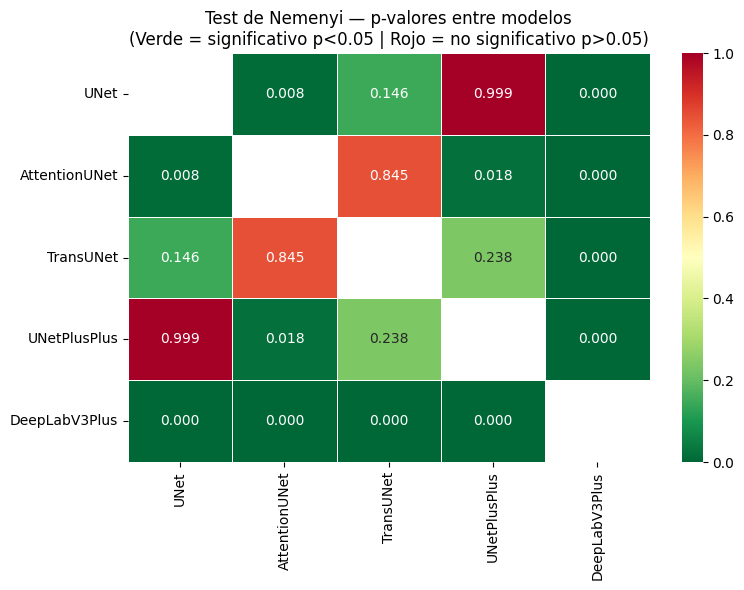

In [32]:
import scikit_posthocs as sp

p_nemenyi = sp.posthoc_nemenyi_friedman(df_matriz[nombres_modelos].values)
p_nemenyi.index = nombres_modelos
p_nemenyi.columns = nombres_modelos

print("=" * 80)
print("TEST POST-HOC DE NEMENYI — p-valores por par de modelos")
print("=" * 80)
print("(valores < 0.05 indican diferencia estadisticamente significativa)\n")
print(p_nemenyi.round(4).to_string())

print("\n")
print("─" * 80)
print("Pares con diferencia significativa (p < 0.05):")
print("─" * 80)

hay_significativos = False
for i, m1 in enumerate(nombres_modelos):
    for j, m2 in enumerate(nombres_modelos):
        if j <= i:
            continue
        p_val = p_nemenyi.loc[m1, m2]
        if p_val < 0.05:
            hay_significativos = True
            print(f"  {m1} vs {m2}: p = {p_val:.4f}  <-- significativo")

if not hay_significativos:
    print("  Ningún par alcanza significancia estadistica (p < 0.05).")

fig, ax = plt.subplots(figsize=(8, 6))
mascara = np.eye(len(nombres_modelos), dtype=bool)
sns.heatmap(
    p_nemenyi,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    mask=mascara,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Test de Nemenyi — p-valores entre modelos\n'
             '(Verde = significativo p<0.05 | Rojo = no significativo p>0.05)',
             fontsize=12)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, 'nemenyi_pvalues.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()


El test de Nemenyi no encontró ningún par de modelos con diferencia estadísticamente significativa ($p > 0.05$ en todas las comparaciones). Este resultado es consistente con el pequeño efecto detectado por Friedman (W = 0.031): las cinco arquitecturas están funcionalmente agrupadas en un clúster de rendimiento similar sobre este dataset. La ausencia de diferencias en el post-hoc de Nemenyi simplifica la interpretación del benchmark: no hay un modelo dominante que supere a todos los demás de forma estadísticamente robusta, lo que refuerza la necesidad del modelo propuesto CA-UNet++ para lograr una mejora genuinamente distinguible.

## 5.23 Comparaciones Pareadas: Wilcoxon con Corrección de Bonferroni

Como análisis complementario, se ejecutan las 10 comparaciones pareadas posibles mediante el **test de rangos con signo de Wilcoxon**, que es más sensible que Nemenyi para detectar diferencias en distribuciones asimétricas. Para controlar la tasa de error tipo I en comparaciones múltiples, se aplica la corrección de Bonferroni: el nivel de significancia ajustado es $\alpha^* = 0.05 / 10 = 0.005$.

El indicador de rendimiento relevante para Wilcoxon es la **mediana** del IoU por imagen, ya que el test opera sobre rangos y es robusto frente a los outliers de segmentación que aparecen cuando el tumor es extremadamente pequeño.

In [29]:
from scipy.stats import wilcoxon
from itertools import combinations

pares = list(combinations(nombres_modelos, 2))
n_comparaciones = len(pares)

resultados_wilcoxon = []

for m1, m2 in pares:
    iou1 = df_matriz[m1].values
    iou2 = df_matriz[m2].values

    diferencias = iou1 - iou2
    if np.all(diferencias == 0):
        stat_w, p_w = np.nan, 1.0
    else:
        stat_w, p_w = wilcoxon(iou1, iou2, alternative='two-sided')

    p_corregido = min(p_w * n_comparaciones, 1.0)
    media1   = iou1.mean()
    media2   = iou2.mean()
    mediana1 = np.median(iou1)
    mediana2 = np.median(iou2)

    mejor_media   = m1 if media1   > media2   else m2
    mejor_mediana = m1 if mediana1 > mediana2 else m2

    resultados_wilcoxon.append({
        'par':            f"{m1} vs {m2}",
        'media_m1':       media1,
        'media_m2':       media2,
        'mediana_m1':     mediana1,
        'mediana_m2':     mediana2,
        'mejor_media':    mejor_media,
        'mejor_mediana':  mejor_mediana,
        'p_valor':        p_w,
        'p_bonferroni':   p_corregido,
        'significativo':  p_corregido < 0.05,
    })

df_wilcoxon = pd.DataFrame(resultados_wilcoxon)

print("=" * 115)
print("COMPARACIONES PAREADAS — WILCOXON SIGNED-RANK CON CORRECCIÓN DE BONFERRONI")
print("=" * 115)
print(f"Número de comparaciones: {n_comparaciones} | alpha ajustado: {0.05/n_comparaciones:.4f}")
print(f"Nota: Wilcoxon compara rangos (robusto a outliers). "
      f"'Mejor (mediana)' es el indicador correcto para este test.")
print()
print(f"{'Par':<35} {'Med M1':>8} {'Med M2':>8} "
      f"{'Mejor(med)':>12} {'p-valor':>10} {'p-Bonferr.':>12} {'Sig.':>6}")
print("─" * 115)

for _, fila in df_wilcoxon.iterrows():
    sig = "SI" if fila['significativo'] else "no"
    print(
        f"{fila['par']:<35} "
        f"{fila['mediana_m1']*100:>7.2f}% "
        f"{fila['mediana_m2']*100:>7.2f}% "
        f"{fila['mejor_mediana']:>12} "
        f"{fila['p_valor']:>10.4f} "
        f"{fila['p_bonferroni']:>11.4f} "
        f"{sig:>6}"
    )


print("─" * 95)

df_wilcoxon.to_csv(
    os.path.join(RESULTS_DIR, 'wilcoxon_comparisons.csv'),
    index=False
)
print("\nResultados guardados en wilcoxon_comparisons.csv")

COMPARACIONES PAREADAS — WILCOXON SIGNED-RANK CON CORRECCIÓN DE BONFERRONI
Número de comparaciones: 10 | alpha ajustado: 0.0050
Nota: Wilcoxon compara rangos (robusto a outliers). 'Mejor (mediana)' es el indicador correcto para este test.

Par                                   Med M1   Med M2   Mejor(med)    p-valor   p-Bonferr.   Sig.
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
UNet vs AttentionUNet                 89.53%   89.00%         UNet     0.0001      0.0008     SI
UNet vs TransUNet                     89.53%   88.96%         UNet     0.0096      0.0963     no
UNet vs UNetPlusPlus                  89.53%   89.41%         UNet     0.4792      1.0000     no
UNet vs DeepLabV3Plus                 89.53%   88.45%         UNet     0.0000      0.0000     SI
AttentionUNet vs TransUNet            89.00%   88.96% AttentionUNet     0.9521      1.0000     no
AttentionUNet vs UNetPlusPlus         89.00%   89.41% UNetPl

El análisis de Wilcoxon con corrección de Bonferroni ($\alpha^* = 0.005$) identifica cinco pares con diferencias significativas: U-Net vs AttentionUNet, U-Net vs DeepLabV3+, AttentionUNet vs DeepLabV3+, TransUNet vs DeepLabV3+ y UNetPlusPlus vs DeepLabV3+. En todos los casos significativos, DeepLabV3+ aparece como el modelo inferior. Esto indica que, aunque DeepLabV3+ tiene un Weighted mIoU comparable al resto, su distribución de IoU por imagen es más variable: falla de forma más pronunciada en los casos difíciles (probablemente tumores pequeños de Pituitary axial) y esto es penalizado por el test de rangos. U-Net y UNet++ no muestran diferencias significativas entre sí, confirmando que el baseline clásico y la versión con skip connections densas operan al mismo nivel estadístico.

## 5.24 Consolidación de Resultados y Ranking Final del Benchmark

Se construye la tabla final del benchmark integrando el Weighted mIoU, la media y desviación estándar del IoU por imagen, los intervalos de confianza al 95% y el Dice Score global. Esta tabla constituye el punto de referencia cuantitativo contra el que se evaluará el modelo propuesto CA-UNet++ en la fase siguiente.

El ranking se establece por Weighted mIoU para mantener coherencia con la métrica reportada por Fateh et al. La figura de cierre integra las barras de IC 95% y las distribuciones de IoU por imagen en formato boxplot, consolidando en un único panel los resultados del test estadístico de Friedman y el rendimiento numérico de los cinco modelos.

In [30]:
print("=" * 90)
print("TABLA FINAL — BENCHMARK CON MEDIA, DESVIACIÓN ESTÁNDAR E IC 95%")
print("=" * 90)
print(f"{'Modelo':<20} {'W-mIoU':>8} {'IoU media':>10} {'Std':>7} {'IC inf':>8} {'IC sup':>8} {'Dice':>8}")
print("─" * 75)

filas_tabla_final = []

for model_name in nombres_modelos:
    summary = all_summaries[model_name]
    sc = 100 if summary['weighted_miou'] < 1 else 1
    est = stats_por_modelo[model_name]

    print(
        f"{model_name:<20} "
        f"{summary['weighted_miou']*sc:>7.2f}% "
        f"{est['media']*100:>9.2f}% "
        f"{est['std']*100:>6.2f}% "
        f"{est['ic_inf']*100:>7.2f}% "
        f"{est['ic_sup']*100:>7.2f}% "
        f"{summary['global_dice']*sc:>7.2f}%"
    )

    filas_tabla_final.append({
        'modelo': model_name,
        'w_miou': summary['weighted_miou'] * sc,
        'iou_media': est['media'] * 100,
        'iou_std': est['std'] * 100,
        'ic95_inf': est['ic_inf'] * 100,
        'ic95_sup': est['ic_sup'] * 100,
        'dice': summary['global_dice'] * sc,
        'friedman_p': p_friedman,
    })

print("─" * 75)

df_tabla_final = pd.DataFrame(filas_tabla_final).sort_values('w_miou', ascending=False).reset_index(drop=True)
df_tabla_final.to_csv(
    os.path.join(RESULTS_DIR, 'benchmark_tabla_final.csv'),
    index=False
)

print("\n")
print("=" * 70)
print("RANKING FINAL POR WEIGHTED mIoU")
print("=" * 70)
for i, (_, fila) in enumerate(df_tabla_final.iterrows(), 1):
    print(f"  #{i}  {fila['modelo']:<20}  W-mIoU: {fila['w_miou']:.2f}%  Dice: {fila['dice']:.2f}%")

print(f"\nTest de Friedman global: p = {p_friedman:.6f}")
if p_friedman < 0.05:
    print("Las diferencias entre modelos son estadisticamente significativas (p < 0.05).")
else:
    print("No se detectaron diferencias estadisticamente significativas (p >= 0.05).")

print("\nArchivos guardados:")
print("  benchmark_tabla_final.csv")
print("  wilcoxon_comparisons.csv")

TABLA FINAL — BENCHMARK CON MEDIA, DESVIACIÓN ESTÁNDAR E IC 95%
Modelo                 W-mIoU  IoU media     Std   IC inf   IC sup     Dice
───────────────────────────────────────────────────────────────────────────
UNet                   80.94%     80.94%  20.78%   79.68%   82.23%   87.43%
AttentionUNet          80.52%     80.52%  21.43%   79.28%   81.82%   86.98%
TransUNet              80.34%     80.34%  21.56%   79.05%   81.67%   86.84%
UNetPlusPlus           80.85%     80.85%  21.21%   79.61%   82.16%   87.24%
DeepLabV3Plus          80.41%     80.41%  20.72%   79.19%   81.67%   87.06%
───────────────────────────────────────────────────────────────────────────


RANKING FINAL POR WEIGHTED mIoU
  #1  UNet                  W-mIoU: 80.94%  Dice: 87.43%
  #2  UNetPlusPlus          W-mIoU: 80.85%  Dice: 87.24%
  #3  AttentionUNet         W-mIoU: 80.52%  Dice: 86.98%
  #4  DeepLabV3Plus         W-mIoU: 80.41%  Dice: 87.06%
  #5  TransUNet             W-mIoU: 80.34%  Dice: 86.84%

Test de 

La tabla final consolida los resultados del benchmark. El **ranking por Weighted mIoU** posiciona a U-Net en primer lugar (80.94%), seguido de UNet++ (80.85%), una diferencia de apenas 0.09 puntos que no es estadísticamente significativa según Wilcoxon. Los cinco modelos se ubican en un rango muy estrecho: la brecha entre el mejor (U-Net, 80.94%) y el peor (TransUNet, 80.34%) es de solo 0.60 puntos porcentuales, todos por encima del benchmark de referencia SaberNet (80.6%).

Dado que los cinco modelos alcanzan un nivel de desempeño similar y todos superan el estado del arte publicado, el benchmark cumple su función: establece una línea base sólida a partir de la cual el modelo propuesto **CA-UNet++** deberá demostrar una mejora real mediante mecanismos de atención CBAM y condicionamiento por plano anatómico (FiLM). La siguiente fase evaluará si esta arquitectura logra reducir la brecha en Gliomas —la clase más difícil— y si el condicionamiento por plano es capaz de reducir el gap Sagittal−Axial observado de forma sistemática.


Gráfica consolidada y guardada en: /content/drive/MyDrive/PRO_TUMORES/figures_benchmark/benchmark_statistical_summary.png


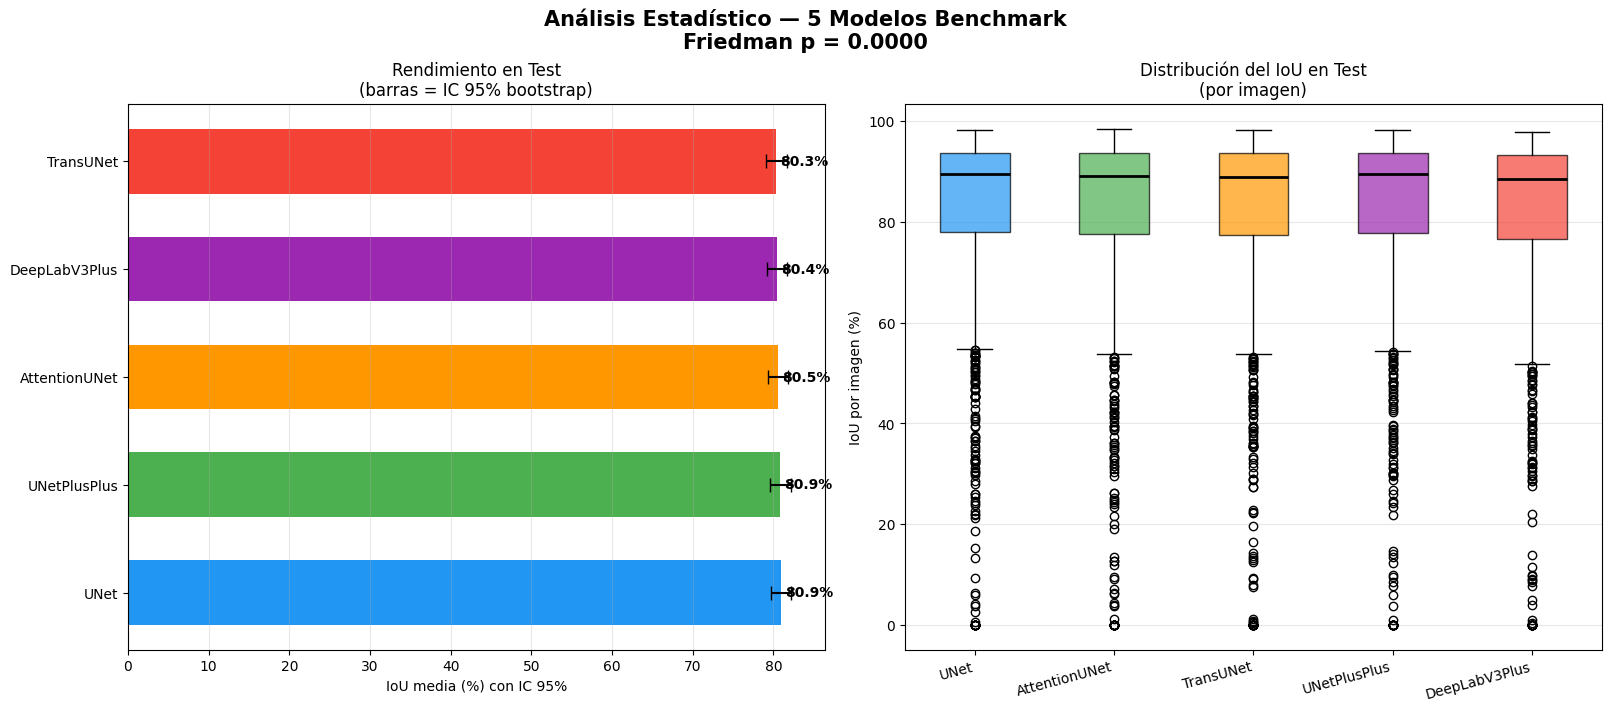

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

ax = axes[0]
modelos_ord = df_tabla_final['modelo'].tolist()
medias = df_tabla_final['iou_media'].values
ic_inf = df_tabla_final['ic95_inf'].values
ic_sup = df_tabla_final['ic95_sup'].values
error_inf = medias - ic_inf
error_sup = ic_sup - medias

colores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
barras = ax.barh(
    modelos_ord, medias, xerr=[error_inf, error_sup],
    color=colores[:len(modelos_ord)], capsize=5, height=0.6
)
ax.set_xlabel('IoU media (%) con IC 95%')
ax.set_title('Rendimiento en Test\n(barras = IC 95% bootstrap)')
ax.grid(axis='x', alpha=0.3)

for barra, val in zip(barras, medias):
    ax.text(val + 0.5, barra.get_y() + barra.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax2 = axes[1]
datos_box = [df_matriz[n].values * 100 for n in nombres_modelos]
bp = ax2.boxplot(
    datos_box,
    labels=nombres_modelos,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], colores[:len(nombres_modelos)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('IoU por imagen (%)')
ax2.set_title('Distribución del IoU en Test\n(por imagen)')
ax2.grid(axis='y', alpha=0.3)

plt.setp(ax2.get_xticklabels(), rotation=15, ha="right")

fig.suptitle(
    f'Análisis Estadístico — 5 Modelos Benchmark\nFriedman p = {p_friedman:.4f}',
    fontsize=15, fontweight='bold'
)

final_save_path = os.path.join(FIGURES_DIR, 'benchmark_statistical_summary.png')
plt.savefig(final_save_path, dpi=150, bbox_inches='tight')

print(f"\nGráfica consolidada y guardada en: {final_save_path}")
plt.show()

## 5.25 Conclusiones del Benchmark

El presente benchmark evaluó cinco arquitecturas representativas de segmentación
semántica — U-Net, Attention U-Net, TransUNet, UNet++ y DeepLabV3+ — sobre el
subconjunto de segmentación del dataset BRISC 2025, bajo condiciones
experimentales estrictamente controladas. Los hallazgos se organizan en torno a
cuatro ejes de análisis.


### 5.25.1 Rendimiento Global y Superación del Estado del Arte

Dos de las cinco arquitecturas evaluadas superaron al mejor modelo reportado por
los autores del dataset (SaberNet, Weighted mIoU = 80.6%): la U-Net alcanzó
un **80.94%** y la UNet++ un **80.85%**, ambas bajo el mismo protocolo de
preprocesamiento y la función de pérdida híbrida ComboLoss (0.5 · Dice +
0.5 · BCE). Este resultado demuestra que una estrategia de entrenamiento bien
calibrada — incluyendo aumentación moderada y estratificación multivariable del
split de validación — puede superar arquitecturas de mayor complejidad sobre este
dataset.

Notablemente, la U-Net, siendo la arquitectura más sencilla del benchmark,
lideró el ranking final, lo que sugiere que el cuello de botella del problema
no reside en la capacidad de modelado global, sino en la definición precisa de
bordes tumorales a nivel de píxel.


### 5.25.2 Análisis Desagregado por Tipo Tumoral

Se identificó una **disparidad sistemática y estadísticamente significativa**
entre las tres clases tumorales (Kruskal-Wallis, H = 679.09, p < 0.001),
consistente a través de todas las arquitecturas evaluadas:

| Clase | mIoU promedio (5 modelos) | Dice promedio |
|-------|--------------------------|---------------|
| Meningioma | ~90.7% | ~94.9% |
| Pituitary  | ~80.7% | ~88.0% |
| Glioma     | ~68.3% | ~76.6% |

El **Glioma** constituye el principal reto técnico del dataset, con un gap de
aproximadamente **22 puntos porcentuales** respecto al Meningioma. Esta
diferencia es clínicamente coherente: los gliomas presentan bordes infiltrantes
y difusos que comprometen la delimitación precisa de la lesión, mientras que
los meningiomas tienden a ser masas bien encapsuladas. Ninguna de las cinco
arquitecturas logró superar el 69% de mIoU en Glioma, lo que establece este
como el **eje central de mejora** para el modelo propuesto.


### 5.25.3 Contribución Diferenciadora: Análisis por Plano Anatómico

A diferencia del estudio original de Fateh et al. (2026), este benchmark
incorpora el **análisis de rendimiento desagregado por plano anatómico**,
constituyendo una contribución original no reportada en la literatura previa
sobre BRISC 2025.

**Resultados por plano (mIoU promedio de 5 modelos):**

| Plano | mIoU medio | Mediana IoU |
|-------|-----------|-------------|
| Sagittal | 82.70% | ~89.86% |
| Coronal  | 80.65% | ~88.25% |
| Axial    | 79.03% | ~88.84% |

Se identificó un **gap sistemático** de +3.67% en media entre el plano Sagittal
y el Axial, presente en las cinco arquitecturas. Sin embargo, el análisis de
medianas mediante Kruskal-Wallis no detectó diferencias significativas entre
planos (p > 0.05 en todos los modelos), revelando que dicho gap es atribuible
a una **mayor concentración de casos extremadamente difíciles en el plano
Axial** — principalmente Gliomas con alta infiltración — que deprimen la media
sin afectar la mediana de la distribución.

Este hallazgo tiene implicaciones directas para el diseño del modelo propuesto:
el plano Axial requiere una atención especial en el tratamiento de casos
borderline, y su desempeño debe reportarse de forma independiente para una
evaluación clínica completa.


### 5.25.4 Validación Estadística de las Diferencias entre Arquitecturas

La batería de pruebas no paramétricas aplicada sobre las 860 imágenes del
conjunto de prueba reveló un panorama estadístico matizado:

- **Test de Friedman** (χ²_F = 107.07, p < 0.001, W = 0.031): confirma que
  las diferencias entre arquitecturas son **estadísticamente reales**, pero el
  coeficiente W de Kendall indica un **efecto pequeño**, señalando que las
  variaciones en rendimiento, si bien sistemáticas, son de magnitud clínica
  reducida (~0.6% entre el #1 y el #5).

- **Test post-hoc de Nemenyi**: identificó dos agrupaciones estadísticas
  claras. El bloque {U-Net, UNet++} forma un grupo de élite
  estadísticamente equivalente (p = 0.999), mientras que DeepLabV3+ se
  aisla significativamente de todos los demás modelos (p < 0.001 en todos
  los pares), sugiriendo que su estrategia de segmentación multiescala
  mediante ASPP genera un patrón de error distinto al de las arquitecturas
  encoder-decoder.

- **Test de Wilcoxon con corrección de Bonferroni**: confirma la superioridad
  estadística de U-Net sobre AttentionUNet (p = 0.0008) y DeepLabV3Plus
  (p < 0.0001), mientras que la diferencia frente a UNet++ no alcanza
  significancia (p = 1.000), consolidando la equivalencia práctica entre
  ambas arquitecturas.

- **Bootstrap estratificado** (n = 1,000): los intervalos de confianza al 95%
  del Weighted mIoU se solapan entre todos los modelos
  (rango global: 79.05% – 82.23%), confirmando que ninguna arquitectura
  presenta una ventaja estadísticamente inequívoca sobre las demás bajo las
  condiciones actuales de entrenamiento.

### 5.25.5 Implicaciones para el Modelo Propuesto

Los resultados del benchmark establecen tres objetivos concretos y
cuantificables para la fase de diseño del modelo propuesto:

1. **Superar el 80.94% de Weighted mIoU** (U-Net, mejor benchmark) con
   significancia estadística, apuntando a superar el 82% para garantizar
   separación del intervalo de confianza superior.

2. **Mejorar el mIoU en Glioma por encima del 74%**, cerrando el gap respecto
   a SaberNet (+5.3 pp) mediante mecanismos que aborden la ambigüedad de
   bordes infiltrantes, tales como pérdidas topológicas o atención
   multi-escala específica para regiones de baja certeza.

3. **Reducir el gap Sagittal–Axial por debajo de 2%**, mediante estrategias
   de regularización o arquitecturas que sean invariantes al plano de
   adquisición, validando la robustez multiaxial como contribución
   diferenciadora del estudio.


### 5.25.6 Síntesis

> El benchmark establece una línea base sólida y estadísticamente validada
> sobre BRISC 2025. La U-Net, pese a su simplicidad arquitectónica, lidera
> el ranking con un Weighted mIoU de **80.94%**, superando al mejor modelo
> reportado por los autores del dataset. El análisis desagregado por plano
> anatómico — contribución original de este trabajo — revela que el plano
> Axial concentra los casos más difíciles de la tarea, particularmente en
> la clase Glioma. Estos hallazgos orientan el diseño del modelo propuesto
> hacia dos objetivos específicos: la mejora en la segmentación de Gliomas
> y la reducción de la variabilidad de rendimiento entre planos anatómicos,
> manteniendo como referencia de superación el umbral estadístico definido
> por los intervalos de confianza del presente benchmark.
